In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    cohen_kappa_score
)



In [4]:
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [7]:
metadata_path = "/kaggle/input/datasets/aditik1234/unified-metadata/unified_metadata.csv"

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (42541, 44)


/tmp/ipykernel_58/560596716.py:3: DtypeWarning: Columns (4,27,28,29,30,38,39,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_path)


,dataset,image_key,image_id,source_split,official_split,image_path,extension,label_dr,has_label,label_source,...,processed_format,preprocess_status,dataset_source,dme_label,dme_label_source,dme_label_scheme,lesion_available,lesion_annotation_type,patient_id,patient_id_status
0,aptos,aptos__8a58801bb4e89fda,000c1434d8d7,train,NaN,data/raw/aptos/train_images/000c1434d8d7.png,.png,2.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
1,aptos,aptos__c8827d05711175da,001639a390f0,train,NaN,data/raw/aptos/train_images/001639a390f0.png,.png,4.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
2,aptos,aptos__2b8228ecc008b575,0024cdab0c1e,train,NaN,data/raw/aptos/train_images/0024cdab0c1e.png,.png,1.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
3,aptos,aptos__f9409e06017fe46c,002c21358ce6,train,NaN,data/raw/aptos/train_images/002c21358ce6.png,.png,0.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
4,aptos,aptos__11b2efaae2c39263,005b95c28852,train,NaN,data/raw/aptos/train_images/005b95c28852.png,.png,0.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files


In [8]:
print(df.columns.tolist())

['dataset', 'image_key', 'image_id', 'source_split', 'official_split', 'image_path', 'extension', 'label_dr', 'has_label', 'label_source', 'is_readable', 'width', 'height', 'pil_format', 'validation_error', 'label_dr_standard', 'dr_grade_name', 'eligible_for_model', 'model_split', 'split_reason', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'dark_pixel_fraction', 'bright_pixel_fraction', 'quality_flag_auto', 'quality_label', 'quality_label_source', 'duplicate_group', 'duplicate_type', 'review_status', 'processed_path', 'processed_width', 'processed_height', 'processed_format', 'preprocess_status', 'dataset_source', 'dme_label', 'dme_label_source', 'dme_label_scheme', 'lesion_available', 'lesion_annotation_type', 'patient_id', 'patient_id_status']


In [9]:
important_columns = [
    "dataset",
    "image_path",
    "processed_path",
    "label_dr_standard",
    "dr_grade_name",
    "eligible_for_model",
    "model_split"
]

for col in important_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(20))
    else:
        print(f"\nWARNING: Column '{col}' not found")


dataset:
dataset
eyepacs      35126
aptos         5590
messidor2     1744
idrid           81
Name: count, dtype: int64

image_path:
image_path
data/raw/messidor2/preprocess/IM004832.JPG      1
data/raw/aptos/train_images/000c1434d8d7.png    1
data/raw/aptos/train_images/001639a390f0.png    1
data/raw/aptos/train_images/0024cdab0c1e.png    1
data/raw/aptos/train_images/002c21358ce6.png    1
data/raw/aptos/train_images/005b95c28852.png    1
data/raw/aptos/train_images/0083ee8054ee.png    1
data/raw/aptos/train_images/0097f532ac9f.png    1
data/raw/aptos/train_images/00a8624548a9.png    1
data/raw/aptos/train_images/00b74780d31d.png    1
data/raw/aptos/train_images/00cb6555d108.png    1
data/raw/aptos/train_images/00cc2b75cddd.png    1
data/raw/aptos/train_images/00e4ddff966a.png    1
data/raw/messidor2/preprocess/IM004528.JPG      1
data/raw/messidor2/preprocess/IM004529.JPG      1
data/raw/messidor2/preprocess/IM004537.JPG      1
data/raw/messidor2/preprocess/IM004538.JPG      1
data/r

In [10]:
model_df = df[
    df["eligible_for_model"] == True
].copy()

print("Total images:", len(df))
print("Eligible images:", len(model_df))
print("Excluded images:", len(df) - len(model_df))

Total images: 42541
Eligible images: 40613
Excluded images: 1928


In [11]:
print(model_df["model_split"].value_counts(dropna=False))

model_split
train         32530
validation     8056
test             27
Name: count, dtype: int64


In [13]:
model_df["model_split"] = (
    model_df["model_split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model_df["model_split"] = model_df["model_split"].replace({
    "validation": "val",
    "valid": "val"
})

print(model_df["model_split"].value_counts())

model_split
train    32530
val       8056
test        27
Name: count, dtype: int64


In [14]:
train_df = model_df[
    model_df["model_split"] == "train"
].copy()

val_df = model_df[
    model_df["model_split"] == "val"
].copy()

test_df = model_df[
    model_df["model_split"] == "test"
].copy()

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 32530
Validation images: 8056
Test images: 27


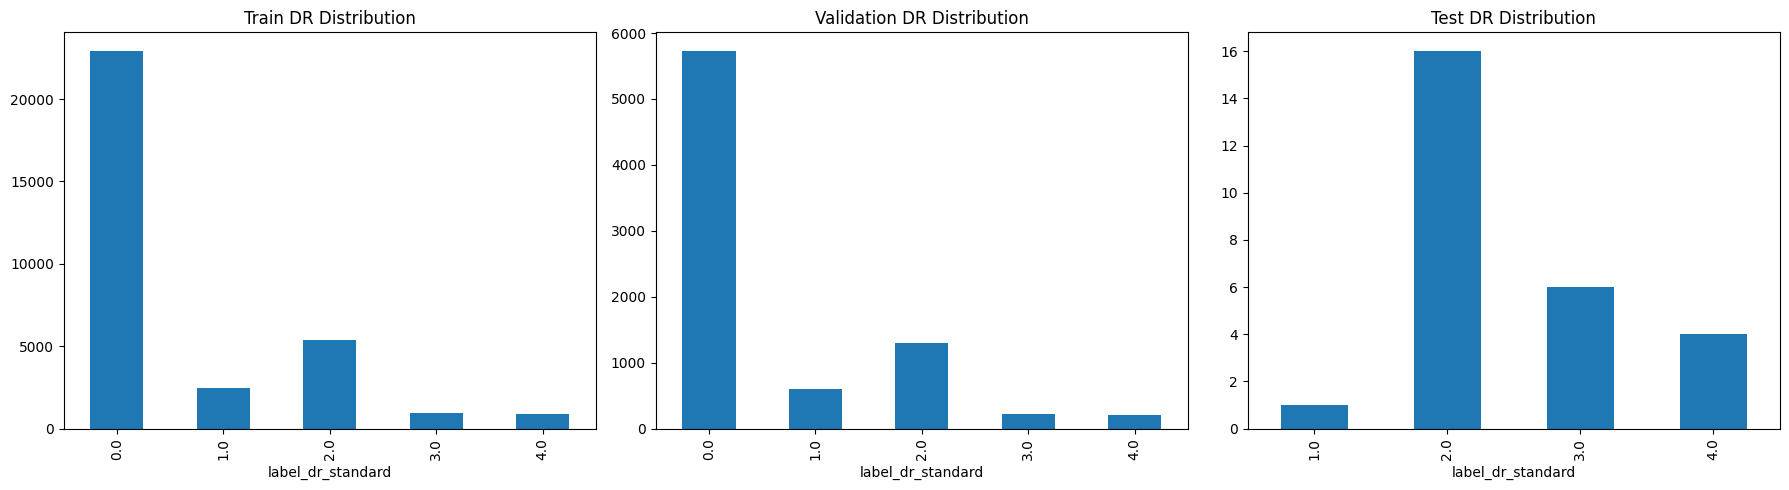

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    title="Train DR Distribution"
)

val_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    title="Validation DR Distribution"
)

test_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2],
    title="Test DR Distribution"
)

plt.tight_layout()
plt.show()

In [16]:
for name, split_df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():
    
    print(f"\n{name} Dataset Distribution:")
    print(split_df["dataset"].value_counts())


Train Dataset Distribution:
dataset
eyepacs      28100
aptos         2978
messidor2     1398
idrid           54
Name: count, dtype: int64

Validation Dataset Distribution:
dataset
eyepacs      7026
aptos         684
messidor2     346
Name: count, dtype: int64

Test Dataset Distribution:
dataset
idrid    27
Name: count, dtype: int64


In [17]:
from pathlib import Path
import os

PROCESSED_ROOT = Path(
    "/kaggle/input/datasets/aditik1234/processed/processed/images"
)

print("Processed root exists:", PROCESSED_ROOT.exists())

print("\nDatasets/folders inside:")
print(os.listdir(PROCESSED_ROOT))

Processed root exists: True

Datasets/folders inside:
['aptos', 'eyepacs', 'messidor2', 'idrid']


In [18]:
def fix_kaggle_path(path):
    
    if pd.isna(path):
        return None
    
    path = str(path).replace("\\", "/")
    
    # Remove the old relative prefix
    prefix = "data/processed/images/"
    
    if path.startswith(prefix):
        relative_path = path[len(prefix):]
    else:
        relative_path = path
    
    # Add the actual Kaggle processed images location
    return str(PROCESSED_ROOT / relative_path)


model_df["final_image_path"] = model_df["processed_path"].apply(
    fix_kaggle_path
)

print(model_df[
    ["processed_path", "final_image_path"]
].head())

                                      processed_path  \
0  data/processed/images/aptos/aptos__8a58801bb4e...   
1  data/processed/images/aptos/aptos__c8827d05711...   
2  data/processed/images/aptos/aptos__2b8228ecc00...   
3  data/processed/images/aptos/aptos__f9409e06017...   
4  data/processed/images/aptos/aptos__11b2efaae2c...   

                                    final_image_path  
0  /kaggle/input/datasets/aditik1234/processed/pr...  
1  /kaggle/input/datasets/aditik1234/processed/pr...  
2  /kaggle/input/datasets/aditik1234/processed/pr...  
3  /kaggle/input/datasets/aditik1234/processed/pr...  
4  /kaggle/input/datasets/aditik1234/processed/pr...  


In [19]:
print("Image path examples:")
print(model_df["image_path"].head())

print("\nProcessed path examples:")
print(model_df["final_image_path"].head())

Image path examples:
0    data/raw/aptos/train_images/000c1434d8d7.png
1    data/raw/aptos/train_images/001639a390f0.png
2    data/raw/aptos/train_images/0024cdab0c1e.png
3    data/raw/aptos/train_images/002c21358ce6.png
4    data/raw/aptos/train_images/005b95c28852.png
Name: image_path, dtype: object

Processed path examples:
0    /kaggle/input/datasets/aditik1234/processed/pr...
1    /kaggle/input/datasets/aditik1234/processed/pr...
2    /kaggle/input/datasets/aditik1234/processed/pr...
3    /kaggle/input/datasets/aditik1234/processed/pr...
4    /kaggle/input/datasets/aditik1234/processed/pr...
Name: final_image_path, dtype: object


In [20]:
print(os.listdir("/kaggle/input"))

['datasets']


In [21]:
sample_paths = model_df["final_image_path"].dropna().head(10)

for path in sample_paths:
    print(path, "->", os.path.exists(path))

/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__8a58801bb4e89fda.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__c8827d05711175da.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__2b8228ecc008b575.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__f9409e06017fe46c.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__11b2efaae2c39263.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__2a1c2e5e9b4f774b.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__9b0b1f3110f4a445.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__56f97594ad38fa59.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__73fd205e1180581e.jpg -> True
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos_

In [22]:
print("Current working directory:")
print(os.getcwd())

print("\nFirst 10 processed paths:")
print(model_df["final_image_path"].dropna().head(10).to_list())

print("\nFirst 10 original image paths:")
print(model_df["image_path"].dropna().head(10).to_list())

Current working directory:
/kaggle/working

First 10 processed paths:
['/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__8a58801bb4e89fda.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__c8827d05711175da.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__2b8228ecc008b575.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__f9409e06017fe46c.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__11b2efaae2c39263.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__2a1c2e5e9b4f774b.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__9b0b1f3110f4a445.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__56f97594ad38fa59.jpg', '/kaggle/input/datasets/aditik1234/processed/processed/images/aptos/aptos__73fd205e1180581e.jpg', '/kaggle/input/datasets/aditik1234/processed/pr

In [23]:
print(os.listdir(".."))

['lib', 'input', 'working']


In [24]:
from pathlib import Path
import os

PROCESSED_ROOT = Path(
    "/kaggle/input/datasets/aditik1234/processed/processed/images"
)

print("Processed images folder exists:")
print(PROCESSED_ROOT.exists())

print("\nContents:")
if PROCESSED_ROOT.exists():
    print(os.listdir(PROCESSED_ROOT))

Processed images folder exists:
True

Contents:
['aptos', 'eyepacs', 'messidor2', 'idrid']


In [29]:
from torch.utils.data import Dataset
from PIL import Image

class DRDataset(Dataset):
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        
        row = self.dataframe.iloc[index]

        image_path = row["final_image_path"]
        label = int(row["label_dr_standard"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [31]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
from pathlib import Path
import os
import pandas as pd

PROCESSED_ROOT = Path(
    "/kaggle/input/datasets/aditik1234/processed/processed/images"
)

def fix_kaggle_path(path):
    
    if pd.isna(path):
        return None

    path = str(path).replace("\\", "/")

    prefix = "data/processed/images/"

    if path.startswith(prefix):
        relative_path = path[len(prefix):]
    else:
        relative_path = path

    return str(PROCESSED_ROOT / relative_path)


model_df["final_image_path"] = model_df["processed_path"].apply(
    fix_kaggle_path
)

model_df["path_exists"] = model_df["final_image_path"].apply(
    lambda x: os.path.exists(x) if x else False
)

print("Valid images:", model_df["path_exists"].sum())
print("Invalid images:", (~model_df["path_exists"]).sum())

model_df[
    ["processed_path", "final_image_path", "path_exists"]
].head()

Valid images: 40613
Invalid images: 0


,processed_path,final_image_path,path_exists
0,data/processed/images/aptos/aptos__8a58801bb4e...,/kaggle/input/datasets/aditik1234/processed/pr...,True
1,data/processed/images/aptos/aptos__c8827d05711...,/kaggle/input/datasets/aditik1234/processed/pr...,True
2,data/processed/images/aptos/aptos__2b8228ecc00...,/kaggle/input/datasets/aditik1234/processed/pr...,True
3,data/processed/images/aptos/aptos__f9409e06017...,/kaggle/input/datasets/aditik1234/processed/pr...,True
4,data/processed/images/aptos/aptos__11b2efaae2c...,/kaggle/input/datasets/aditik1234/processed/pr...,True


In [29]:
model_df = model_df[
    model_df["path_exists"]
].copy()

train_df = model_df[
    model_df["model_split"] == "train"
].copy()

val_df = model_df[
    model_df["model_split"] == "val"
].copy()

test_df = model_df[
    model_df["model_split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nColumns in train_df:")
print(train_df.columns.tolist())

Train: 32530
Validation: 8056
Test: 27

Columns in train_df:
['dataset', 'image_key', 'image_id', 'source_split', 'official_split', 'image_path', 'extension', 'label_dr', 'has_label', 'label_source', 'is_readable', 'width', 'height', 'pil_format', 'validation_error', 'label_dr_standard', 'dr_grade_name', 'eligible_for_model', 'model_split', 'split_reason', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'dark_pixel_fraction', 'bright_pixel_fraction', 'quality_flag_auto', 'quality_label', 'quality_label_source', 'duplicate_group', 'duplicate_type', 'review_status', 'processed_path', 'processed_width', 'processed_height', 'processed_format', 'preprocess_status', 'dataset_source', 'dme_label', 'dme_label_source', 'dme_label_scheme', 'lesion_available', 'lesion_annotation_type', 'patient_id', 'patient_id_status', 'final_image_path', 'path_exists']


In [30]:
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = DRDataset(
    test_df,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 32530
Validation: 8056
Test: 27


In [31]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 2


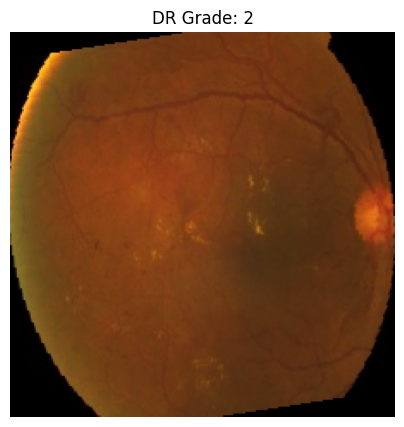

In [32]:
import numpy as np
import matplotlib.pyplot as plt

image, label = train_dataset[0]

image_np = image.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image_np * std + mean
image_np = np.clip(image_np, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title(f"DR Grade: {label}")
plt.axis("off")
plt.show()

In [33]:
from torch.utils.data import DataLoader
import torch

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [34]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

print("Labels:")
print(labels)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels:
tensor([2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        0, 0, 0, 0, 1, 2, 0, 0])


In [35]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [36]:
class_counts = (
    train_df["label_dr_standard"]
    .value_counts()
    .sort_index()
)

print(class_counts)

label_dr_standard
0.0    22908
1.0     2479
2.0     5356
3.0      932
4.0      855
Name: count, dtype: int64


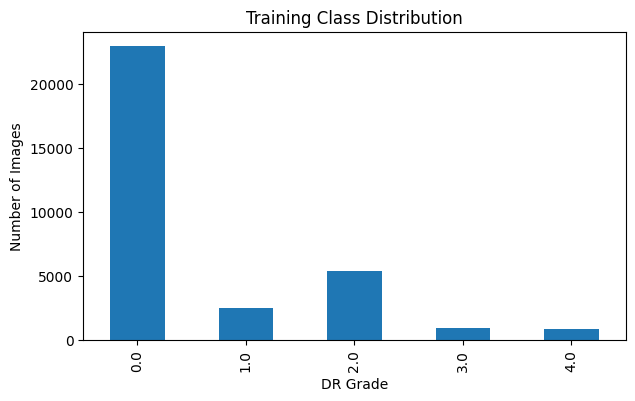

In [36]:
plt.figure(figsize=(7, 4))

class_counts.plot(kind="bar")

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("Training Class Distribution")

plt.show()

In [37]:
class_counts = class_counts.reindex(
    [0, 1, 2, 3, 4],
    fill_value=1
)

class_weights = len(train_df) / (
    5 * class_counts
)

print("Class weights:")
print(class_weights)

Class weights:
label_dr_standard
0    0.284006
1    2.624445
2    1.214712
3    6.980687
4    7.609357
Name: count, dtype: float64


In [38]:
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)

print(class_weights_tensor)

tensor([0.2840, 2.6244, 1.2147, 6.9807, 7.6094], device='cuda:0')


In [39]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    5
)

model = model.to(device)

print("Model loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s] 


Model loaded successfully


In [53]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function and optimizer ready")

Loss function and optimizer ready


In [43]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_accuracy

In [44]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probabilities)
    )

In [56]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_resnet18_baseline.pth"
        )

        print("✓ Best model saved")


Epoch 1/10
Train Loss: 1.2670 | Train Accuracy: 0.4886
Val Loss: 1.1504 | Val Accuracy: 0.6089
✓ Best model saved

Epoch 2/10
Train Loss: 1.1291 | Train Accuracy: 0.5450
Val Loss: 1.1006 | Val Accuracy: 0.5660
✓ Best model saved

Epoch 3/10
Train Loss: 1.0640 | Train Accuracy: 0.5724
Val Loss: 1.0939 | Val Accuracy: 0.6390
✓ Best model saved

Epoch 4/10
Train Loss: 1.0161 | Train Accuracy: 0.5926
Val Loss: 1.0605 | Val Accuracy: 0.6395
✓ Best model saved

Epoch 5/10
Train Loss: 0.9628 | Train Accuracy: 0.5981
Val Loss: 1.0748 | Val Accuracy: 0.6442

Epoch 6/10
Train Loss: 0.9221 | Train Accuracy: 0.6063
Val Loss: 1.0561 | Val Accuracy: 0.5494
✓ Best model saved

Epoch 7/10
Train Loss: 0.8793 | Train Accuracy: 0.6123
Val Loss: 1.1419 | Val Accuracy: 0.5369

Epoch 8/10
Train Loss: 0.8195 | Train Accuracy: 0.6377
Val Loss: 1.1290 | Val Accuracy: 0.6270

Epoch 9/10
Train Loss: 0.7666 | Train Accuracy: 0.6562
Val Loss: 1.2689 | Val Accuracy: 0.7054

Epoch 10/10
Train Loss: 0.7161 | Train A

In [57]:
# Best model weights
BEST_MODEL_PATH = "/kaggle/working/best_resnet18_baseline.pth"

# Create a more complete checkpoint using the ACTUAL best weights
best_weights = torch.load(BEST_MODEL_PATH, map_location="cpu")

checkpoint = {
    "model_name": "ResNet18",
    "num_classes": 5,
    "model_state_dict": best_weights,
    "history": history
}

torch.save(
    checkpoint,
    "/kaggle/working/best_resnet18_checkpoint.pth"
)

print("Saved successfully!")

Saved successfully!


In [58]:
test_loss, test_accuracy, test_labels, test_predictions, test_probabilities = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 1.8125
Test Accuracy: 0.0


In [59]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative DR"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

           No DR       0.00      0.00      0.00       0.0
            Mild       0.00      0.00      0.00       1.0
        Moderate       0.00      0.00      0.00      16.0
          Severe       0.00      0.00      0.00       6.0
Proliferative DR       0.00      0.00      0.00       4.0

        accuracy                           0.00      27.0
       macro avg       0.00      0.00      0.00      27.0
    weighted avg       0.00      0.00      0.00      27.0



In [62]:
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score

print(
    classification_report(
        val_labels,
        val_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative DR"
        ],
        zero_division=0
    )
)

macro_f1 = f1_score(
    val_labels,
    val_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    val_labels,
    val_predictions,
    average="weighted"
)

qwk = cohen_kappa_score(
    val_labels,
    val_predictions,
    weights="quadratic"
)

print("\nMacro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("QWK:", round(qwk, 4))

                  precision    recall  f1-score   support

           No DR       0.89      0.62      0.73      5724
            Mild       0.13      0.56      0.21       605
        Moderate       0.54      0.35      0.42      1300
          Severe       0.30      0.48      0.37       225
Proliferative DR       0.48      0.68      0.57       202

        accuracy                           0.57      8056
       macro avg       0.47      0.54      0.46      8056
    weighted avg       0.75      0.57      0.63      8056


Macro F1: 0.4612
Weighted F1: 0.6289
QWK: 0.621


In [63]:
baseline_results = pd.DataFrame([{
    "Model": "ResNet18 Baseline",
    "Dataset": "Unified DR Dataset",
    "Validation Accuracy": val_accuracy,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "QWK": qwk,
    "Validation Loss": val_loss
}])

baseline_results

,Model,Dataset,Validation Accuracy,Macro F1,Weighted F1,QWK,Validation Loss
0,ResNet18 Baseline,Unified DR Dataset,0.570382,0.461166,0.628903,0.620998,1.226927


In [64]:
baseline_results.to_csv(
    "/kaggle/working/resnet18_baseline_results.csv",
    index=False
)

print("✓ Baseline results saved")

✓ Baseline results saved


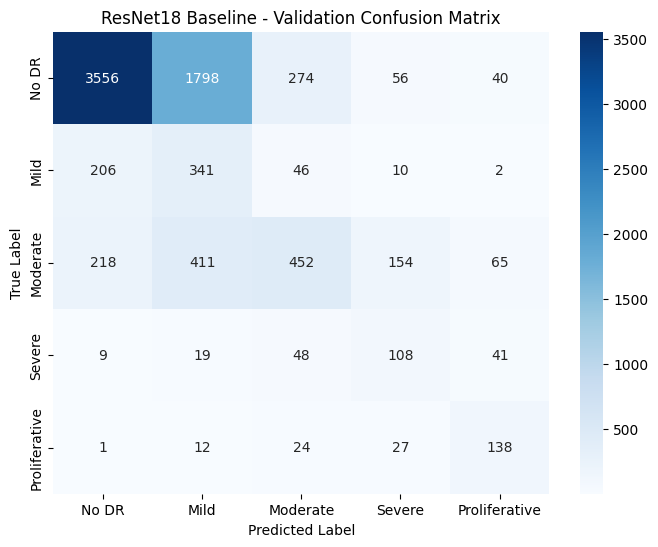

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    val_labels,
    val_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ],
    yticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 Baseline - Validation Confusion Matrix")

plt.show()

In [66]:
import os

print(os.listdir("/kaggle/working"))

['best_resnet18_baseline.pth', '.virtual_documents', 'resnet18_baseline_results.csv', 'best_resnet18_checkpoint.pth']


In [67]:
print(model_df.columns.tolist())

['dataset', 'image_key', 'image_id', 'source_split', 'official_split', 'image_path', 'extension', 'label_dr', 'has_label', 'label_source', 'is_readable', 'width', 'height', 'pil_format', 'validation_error', 'label_dr_standard', 'dr_grade_name', 'eligible_for_model', 'model_split', 'split_reason', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'dark_pixel_fraction', 'bright_pixel_fraction', 'quality_flag_auto', 'quality_label', 'quality_label_source', 'duplicate_group', 'duplicate_type', 'review_status', 'processed_path', 'processed_width', 'processed_height', 'processed_format', 'preprocess_status', 'dataset_source', 'dme_label', 'dme_label_source', 'dme_label_scheme', 'lesion_available', 'lesion_annotation_type', 'patient_id', 'patient_id_status', 'final_image_path', 'path_exists']


In [69]:
print(model_df["label_dr_standard"].value_counts().sort_index())

print("\nTotal:", len(model_df))

label_dr_standard
0.0    28632
1.0     3085
2.0     6672
3.0     1163
4.0     1061
Name: count, dtype: int64

Total: 40613


In [70]:
from sklearn.model_selection import train_test_split

# Keep only rows with valid labels and valid image paths
split_df = model_df[
    model_df["label_dr_standard"].notna() &
    model_df["path_exists"]
].copy()

# Make labels integers
split_df["label_dr_standard"] = split_df["label_dr_standard"].astype(int)

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    split_df,
    test_size=0.30,
    stratify=split_df["label_dr_standard"],
    random_state=42
)

# Second split: divide 30% into 15% validation + 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_dr_standard"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 28429
Validation: 6092
Test: 6092


In [8]:
train_df["model_split"] = "train"
val_df["model_split"] = "val"
test_df["model_split"] = "test"

corrected_split_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

corrected_split_df.to_csv(
    "/kaggle/working/corrected_unified_metadata.csv",
    index=False
)

print("✓ Corrected metadata saved")
print(corrected_split_df["model_split"].value_counts())

NameError: name 'train_df' is not defined

In [71]:
print("TRAIN")
print(train_df["label_dr_standard"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["label_dr_standard"].value_counts().sort_index())

print("\nTEST")
print(test_df["label_dr_standard"].value_counts().sort_index())

TRAIN
label_dr_standard
0    20042
1     2160
2     4670
3      814
4      743
Name: count, dtype: int64

VALIDATION
label_dr_standard
0    4295
1     462
2    1001
3     175
4     159
Name: count, dtype: int64

TEST
label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [73]:
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = DRDataset(
    test_df,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 28429
Validation: 6092
Test: 6092


In [74]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✓ DataLoaders created")

✓ DataLoaders created


In [75]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 0, 0, 2, 0, 0, 1, 0, 0])


In [76]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [77]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    5
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=5, bias=True)


In [78]:
import numpy as np
import torch

class_counts = train_df["label_dr_standard"].value_counts().sort_index()

print("Class counts:")
print(class_counts)

weights = len(train_df) / (
    len(class_counts) * class_counts.values
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")
print(class_weights)

Class counts:
label_dr_standard
0    20042
1     2160
2     4670
3      814
4      743
Name: count, dtype: int64

Class weights:
tensor([0.2837, 2.6323, 1.2175, 6.9850, 7.6525], device='cuda:0')


In [79]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print("Loss function and optimizer ready")

Loss function and optimizer ready


In [80]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(
            outputs,
            labels
        )
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += (
            loss.item() * images.size(0)
        )
        
        _, predicted = torch.max(
            outputs,
            1
        )
        
        correct += (
            predicted == labels
        ).sum().item()
        
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    
    epoch_accuracy = correct / total
    
    return epoch_loss, epoch_accuracy

In [82]:
import torch.nn.functional as F

def evaluate(
    model,
    loader,
    criterion,
    device
):
    
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(
                outputs,
                labels
            )
            
            probabilities = F.softmax(
                outputs,
                dim=1
            )
            
            _, predicted = torch.max(
                outputs,
                1
            )
            
            running_loss += (
                loss.item() * images.size(0)
            )
            
            correct += (
                predicted == labels
            ).sum().item()
            
            total += labels.size(0)
            
            all_labels.extend(
                labels.cpu().numpy()
            )
            
            all_predictions.extend(
                predicted.cpu().numpy()
            )
            
            all_probabilities.extend(
                probabilities.cpu().numpy()
            )
    
    epoch_loss = running_loss / total
    
    epoch_accuracy = correct / total
    
    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [83]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

BEST_MODEL_PATH = "/kaggle/working/best_resnet18_corrected_split.pth"

print("Training setup complete")

Training setup complete


In [84]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "history": history
            },
            BEST_MODEL_PATH
        )

        print("✓ New best model saved")


Epoch 1/10
Train Loss: 1.2779 | Train Accuracy: 0.4882
Val Loss: 1.1721 | Val Accuracy: 0.4833
✓ New best model saved

Epoch 2/10
Train Loss: 1.1369 | Train Accuracy: 0.5457
Val Loss: 1.0781 | Val Accuracy: 0.6097
✓ New best model saved

Epoch 3/10
Train Loss: 1.0638 | Train Accuracy: 0.5676
Val Loss: 1.0945 | Val Accuracy: 0.6454

Epoch 4/10
Train Loss: 1.0197 | Train Accuracy: 0.5842
Val Loss: 1.0970 | Val Accuracy: 0.6413

Epoch 5/10
Train Loss: 0.9720 | Train Accuracy: 0.5945
Val Loss: 1.1275 | Val Accuracy: 0.4243

Epoch 6/10
Train Loss: 0.9224 | Train Accuracy: 0.6021
Val Loss: 1.1407 | Val Accuracy: 0.6840

Epoch 7/10
Train Loss: 0.8752 | Train Accuracy: 0.6181
Val Loss: 1.1386 | Val Accuracy: 0.5105

Epoch 8/10
Train Loss: 0.8195 | Train Accuracy: 0.6306
Val Loss: 1.2138 | Val Accuracy: 0.6706

Epoch 9/10
Train Loss: 0.7688 | Train Accuracy: 0.6438
Val Loss: 1.1052 | Val Accuracy: 0.6014

Epoch 10/10
Train Loss: 0.7253 | Train Accuracy: 0.6538
Val Loss: 1.2528 | Val Accuracy: 

In [85]:
import os

print("Model exists:", os.path.exists(BEST_MODEL_PATH))
print("File size (MB):", os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024))

Model exists: True
File size (MB): 128.06709575653076


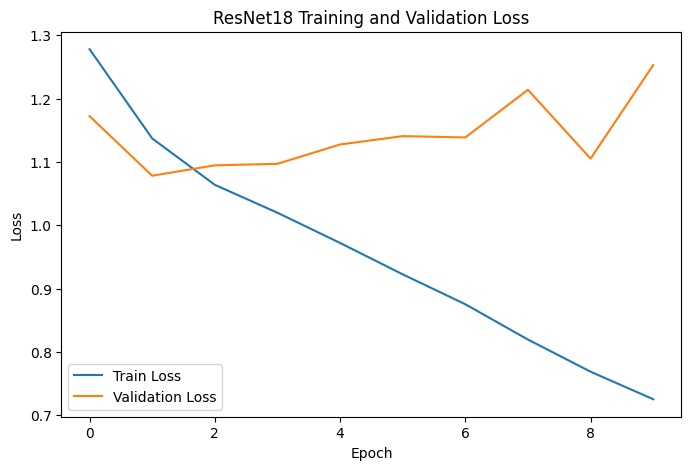

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training and Validation Loss")
plt.legend()

plt.show()

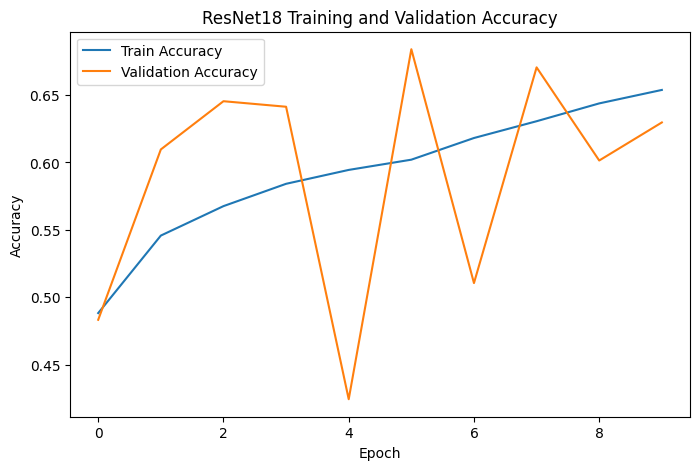

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Training and Validation Accuracy")
plt.legend()

plt.show()

In [88]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

best_model = models.resnet18(
    weights=None
)

num_features = best_model.fc.in_features
best_model.fc = nn.Linear(num_features, 5)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model = best_model.to(device)
best_model.eval()

print("✓ Best model loaded")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

✓ Best model loaded
Best epoch: 2
Best validation loss: 1.0781354599694084
Best validation accuracy: 0.6096520026263953


In [89]:
test_loss, test_accuracy, test_labels, test_predictions, test_probabilities = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 1.0882
Test Accuracy: 0.6131


In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative DR"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

           No DR       0.87      0.69      0.77      4295
            Mild       0.14      0.25      0.18       463
        Moderate       0.37      0.46      0.41      1001
          Severe       0.34      0.41      0.37       174
Proliferative DR       0.31      0.79      0.44       159

        accuracy                           0.61      6092
       macro avg       0.41      0.52      0.44      6092
    weighted avg       0.70      0.61      0.65      6092



In [91]:
from sklearn.metrics import f1_score, cohen_kappa_score

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted"
)

qwk = cohen_kappa_score(
    test_labels,
    test_predictions,
    weights="quadratic"
)

print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("QWK:", round(qwk, 4))

Macro F1: 0.4354
Weighted F1: 0.6456
QWK: 0.5611


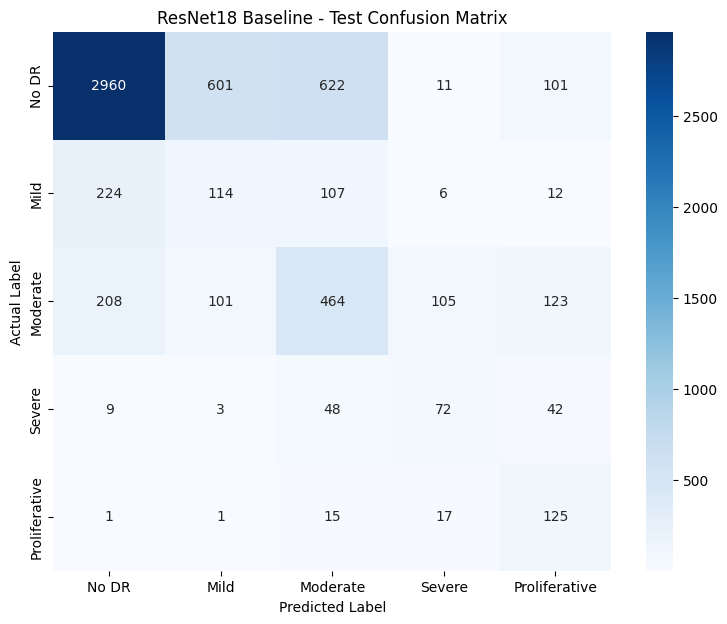

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ],
    yticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ResNet18 Baseline - Test Confusion Matrix")

plt.show()

In [93]:
final_results = pd.DataFrame([{
    "Model": "ResNet18 Baseline",
    "Dataset": "Unified DR Dataset",
    "Test Samples": len(test_labels),
    "Test Loss": test_loss,
    "Test Accuracy": test_accuracy,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "QWK": qwk
}])

final_results

,Model,Dataset,Test Samples,Test Loss,Test Accuracy,Macro F1,Weighted F1,QWK
0,ResNet18 Baseline,Unified DR Dataset,6092,1.088163,0.613099,0.435374,0.645614,0.561066


In [94]:
final_results.to_csv(
    "/kaggle/working/resnet18_final_test_results.csv",
    index=False
)

print("✓ Final test results saved")

✓ Final test results saved


In [95]:
from torchvision import models
import torch.nn as nn

efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

num_features = efficientnet_model.classifier[1].in_features

efficientnet_model.classifier[1] = nn.Linear(
    num_features,
    5
)

efficientnet_model = efficientnet_model.to(device)

print(efficientnet_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [96]:
efficientnet_optimizer = torch.optim.AdamW(
    efficientnet_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print("EfficientNet optimizer ready")

EfficientNet optimizer ready


In [97]:
EPOCHS = 10

efficientnet_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_efficientnet_val_loss = float("inf")

EFFICIENTNET_MODEL_PATH = (
    "/kaggle/working/"
    "best_efficientnet_b0.pth"
)

print("EfficientNet training setup complete")

EfficientNet training setup complete


In [98]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        efficientnet_model,
        train_loader,
        criterion,
        efficientnet_optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        efficientnet_model,
        val_loader,
        criterion,
        device
    )

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["train_accuracy"].append(train_accuracy)

    efficientnet_history["val_loss"].append(val_loss)
    efficientnet_history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_efficientnet_val_loss:

        best_efficientnet_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": efficientnet_model.state_dict(),
                "optimizer_state_dict": efficientnet_optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "history": efficientnet_history
            },
            EFFICIENTNET_MODEL_PATH
        )

        print("✓ New best EfficientNet model saved")


Epoch 1/10
Train Loss: 1.2555 | Train Accuracy: 0.5142
Val Loss: 1.1054 | Val Accuracy: 0.5663
✓ New best EfficientNet model saved

Epoch 2/10
Train Loss: 1.0770 | Train Accuracy: 0.5721
Val Loss: 1.0743 | Val Accuracy: 0.5829
✓ New best EfficientNet model saved

Epoch 3/10
Train Loss: 0.9794 | Train Accuracy: 0.6016
Val Loss: 1.0408 | Val Accuracy: 0.5561
✓ New best EfficientNet model saved

Epoch 4/10
Train Loss: 0.9023 | Train Accuracy: 0.6178
Val Loss: 1.0782 | Val Accuracy: 0.5420

Epoch 5/10
Train Loss: 0.8251 | Train Accuracy: 0.6247
Val Loss: 1.1837 | Val Accuracy: 0.6395

Epoch 6/10
Train Loss: 0.7663 | Train Accuracy: 0.6485
Val Loss: 1.1313 | Val Accuracy: 0.6666

Epoch 7/10
Train Loss: 0.6971 | Train Accuracy: 0.6631
Val Loss: 1.1760 | Val Accuracy: 0.5847

Epoch 8/10
Train Loss: 0.6350 | Train Accuracy: 0.6819
Val Loss: 1.2879 | Val Accuracy: 0.6287

Epoch 9/10
Train Loss: 0.5946 | Train Accuracy: 0.6946
Val Loss: 1.2556 | Val Accuracy: 0.5588

Epoch 10/10
Train Loss: 0.5

In [99]:
import os

print("Model exists:", os.path.exists(EFFICIENTNET_MODEL_PATH))

if os.path.exists(EFFICIENTNET_MODEL_PATH):
    print(
        "Size (MB):",
        round(
            os.path.getsize(EFFICIENTNET_MODEL_PATH) / (1024 * 1024),
            2
        )
    )

Model exists: True
Size (MB): 46.4


In [100]:
checkpoint = torch.load(
    EFFICIENTNET_MODEL_PATH,
    map_location=device
)

best_efficientnet = models.efficientnet_b0(
    weights=None
)

num_features = best_efficientnet.classifier[1].in_features

best_efficientnet.classifier[1] = nn.Linear(
    num_features,
    5
)

best_efficientnet.load_state_dict(
    checkpoint["model_state_dict"]
)

best_efficientnet = best_efficientnet.to(device)

best_efficientnet.eval()

print("✓ Best EfficientNet loaded")
print("Best epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

✓ Best EfficientNet loaded
Best epoch: 3
Best validation accuracy: 0.5561391989494419


In [101]:
(
    efficientnet_test_loss,
    efficientnet_test_accuracy,
    efficientnet_test_labels,
    efficientnet_test_predictions,
    efficientnet_test_probabilities
) = evaluate(
    best_efficientnet,
    test_loader,
    criterion,
    device
)

print(
    "Test Loss:",
    round(efficientnet_test_loss, 4)
)

print(
    "Test Accuracy:",
    round(efficientnet_test_accuracy, 4)
)

Test Loss: 1.0733
Test Accuracy: 0.5486


In [102]:
from sklearn.metrics import f1_score, cohen_kappa_score

efficientnet_macro_f1 = f1_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="macro"
)

efficientnet_weighted_f1 = f1_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="weighted"
)

efficientnet_qwk = cohen_kappa_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    weights="quadratic"
)

print(
    "Macro F1:",
    round(efficientnet_macro_f1, 4)
)

print(
    "Weighted F1:",
    round(efficientnet_weighted_f1, 4)
)

print(
    "QWK:",
    round(efficientnet_qwk, 4)
)

Macro F1: 0.4453
Weighted F1: 0.6039
QWK: 0.5844


In [103]:
comparison_results = pd.DataFrame([
    {
        "Model": "ResNet18",
        "Accuracy": test_accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "QWK": qwk
    },
    {
        "Model": "EfficientNet-B0",
        "Accuracy": efficientnet_test_accuracy,
        "Macro F1": efficientnet_macro_f1,
        "Weighted F1": efficientnet_weighted_f1,
        "QWK": efficientnet_qwk
    }
])

comparison_results

,Model,Accuracy,Macro F1,Weighted F1,QWK
0,ResNet18,0.613099,0.435374,0.645614,0.561066
1,EfficientNet-B0,0.548588,0.445269,0.603916,0.584390


In [104]:
print("Quality label distribution:")
print(
    df["quality_label"]
    .value_counts(dropna=False)
)

print("\nQuality label source:")
print(
    df["quality_label_source"]
    .value_counts(dropna=False)
)

print("\nAutomatic quality flags:")
print(
    df["quality_flag_auto"]
    .value_counts(dropna=False)
)

Quality label distribution:
quality_label
NaN    40797
1.0     1744
Name: count, dtype: int64

Quality label source:
quality_label_source
NaN                               40797
messidor2/adjudicated_gradable     1744
Name: count, dtype: int64

Automatic quality flags:
quality_flag_auto
pass                                      29452
possibly_blurry                           11441
very_dark;possibly_blurry                   941
very_dark                                   405
very_dark;low_contrast;possibly_blurry      241
very_dark;low_contrast                       27
low_contrast;possibly_blurry                 26
low_contrast                                  8
Name: count, dtype: int64


In [105]:
quality_columns = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian_var",
    "dark_pixel_fraction",
    "bright_pixel_fraction",
    "quality_flag_auto",
    "quality_label",
    "quality_label_source"
]

print(df[quality_columns].head())

   brightness_mean  contrast_std  sharpness_laplacian_var  \
0        50.990446     31.261409                46.768915   
1        74.232948     43.365525                29.479918   
2        66.384793     31.165278                78.010500   
3        85.032720     46.333070               291.557499   
4        22.482814     26.219367                49.392446   

   dark_pixel_fraction  bright_pixel_fraction quality_flag_auto  \
0             0.254481                    0.0              pass   
1             0.253957                    0.0              pass   
2             0.167199                    0.0              pass   
3             0.211308                    0.0              pass   
4             0.526733                    0.0         very_dark   

   quality_label quality_label_source  
0            NaN                  NaN  
1            NaN                  NaN  
2            NaN                  NaN  
3            NaN                  NaN  
4            NaN              

IMAGE QUALITY

In [106]:
df["quality_binary"] = (
    df["quality_flag_auto"] == "pass"
).astype(int)

print(df["quality_binary"].value_counts())

print("\nPercentage distribution:")
print(
    df["quality_binary"]
    .value_counts(normalize=True) * 100
)

quality_binary
1    29452
0    13089
Name: count, dtype: int64

Percentage distribution:
quality_binary
1    69.232035
0    30.767965
Name: proportion, dtype: float64


In [107]:
quality_summary = pd.crosstab(
    df["quality_flag_auto"],
    df["quality_binary"]
)

quality_summary

quality_binary,0,1
quality_flag_auto,,
low_contrast,8,0
low_contrast;possibly_blurry,26,0
pass,0,29452
possibly_blurry,11441,0
very_dark,405,0
very_dark;low_contrast,27,0
very_dark;low_contrast;possibly_blurry,241,0
very_dark;possibly_blurry,941,0


In [113]:
print(df["processed_path"].head(10).tolist())

['data/processed/images/aptos/aptos__8a58801bb4e89fda.jpg', 'data/processed/images/aptos/aptos__c8827d05711175da.jpg', 'data/processed/images/aptos/aptos__2b8228ecc008b575.jpg', 'data/processed/images/aptos/aptos__f9409e06017fe46c.jpg', 'data/processed/images/aptos/aptos__11b2efaae2c39263.jpg', 'data/processed/images/aptos/aptos__2a1c2e5e9b4f774b.jpg', 'data/processed/images/aptos/aptos__9b0b1f3110f4a445.jpg', 'data/processed/images/aptos/aptos__56f97594ad38fa59.jpg', 'data/processed/images/aptos/aptos__73fd205e1180581e.jpg', 'data/processed/images/aptos/aptos__2bc5841cf5eee5f8.jpg']


In [114]:
print("Processed dataset location:")

import os

print(os.listdir("/kaggle/input/datasets/aditik1234/processed/"))

Processed dataset location:
['processed']


In [115]:
KAGGLE_PROCESSED_ROOT = "/kaggle/input/datasets/aditik1234/processed/processed"

quality_df = df[
    df["eligible_for_model"] == True
].copy()

quality_df["final_image_path"] = quality_df["processed_path"].apply(
    lambda x: os.path.join(
        KAGGLE_PROCESSED_ROOT,
        str(x).replace("\\", "/")
    )
)

quality_df["path_exists"] = quality_df["final_image_path"].apply(
    os.path.exists
)

print("Total images:", len(quality_df))
print("Images found:", quality_df["path_exists"].sum())
print("Images missing:", (~quality_df["path_exists"]).sum())

quality_df[
    ["processed_path", "final_image_path", "path_exists"]
].head()

Total images: 40613
Images found: 0
Images missing: 40613


,processed_path,final_image_path,path_exists
0,data/processed/images/aptos/aptos__8a58801bb4e...,/kaggle/input/datasets/aditik1234/processed/pr...,False
1,data/processed/images/aptos/aptos__c8827d05711...,/kaggle/input/datasets/aditik1234/processed/pr...,False
2,data/processed/images/aptos/aptos__2b8228ecc00...,/kaggle/input/datasets/aditik1234/processed/pr...,False
3,data/processed/images/aptos/aptos__f9409e06017...,/kaggle/input/datasets/aditik1234/processed/pr...,False
4,data/processed/images/aptos/aptos__11b2efaae2c...,/kaggle/input/datasets/aditik1234/processed/pr...,False


In [116]:
quality_df = quality_df[
    quality_df["path_exists"] == True
].copy()

print("Quality dataset size:", len(quality_df))

print("\nQuality distribution:")
print(
    quality_df["quality_binary"]
    .value_counts()
)

Quality dataset size: 0

Quality distribution:
Series([], Name: count, dtype: int64)


In [117]:
print(
    pd.crosstab(
        quality_df["model_split"],
        quality_df["quality_binary"]
    )
)

Empty DataFrame
Columns: []
Index: []


In [111]:
print("Available path columns:")

path_cols = [
    col for col in df.columns
    if "path" in col.lower()
]

print(path_cols)

Available path columns:
['image_path', 'processed_path']


In [118]:
df["eligible_for_model"] == True

0        True
1        True
2        True
3        True
4        True
         ... 
42536    True
42537    True
42538    True
42539    True
42540    True
Name: eligible_for_model, Length: 42541, dtype: bool

In [119]:
print(df["eligible_for_model"].value_counts(dropna=False))

print("\nData type:")
print(df["eligible_for_model"].dtype)

eligible_for_model
True     40613
False     1928
Name: count, dtype: int64

Data type:
bool


In [120]:
import os
import pandas as pd

KAGGLE_PROCESSED_ROOT = "/kaggle/input/datasets/aditik1234/processed/processed"

quality_df = df.copy()

quality_df["final_image_path"] = quality_df["processed_path"].apply(
    lambda x: os.path.join(
        KAGGLE_PROCESSED_ROOT,
        str(x).replace("\\", "/")
    )
)

quality_df["path_exists"] = quality_df["final_image_path"].apply(os.path.exists)

print("Total rows:", len(quality_df))
print("Images found:", quality_df["path_exists"].sum())
print("Images missing:", (~quality_df["path_exists"]).sum())

print("\nFirst few paths:")
print(
    quality_df[
        ["processed_path", "final_image_path", "path_exists"]
    ].head()
)

Total rows: 42541
Images found: 0
Images missing: 42541

First few paths:
                                      processed_path  \
0  data/processed/images/aptos/aptos__8a58801bb4e...   
1  data/processed/images/aptos/aptos__c8827d05711...   
2  data/processed/images/aptos/aptos__2b8228ecc00...   
3  data/processed/images/aptos/aptos__f9409e06017...   
4  data/processed/images/aptos/aptos__11b2efaae2c...   

                                    final_image_path  path_exists  
0  /kaggle/input/datasets/aditik1234/processed/pr...        False  
1  /kaggle/input/datasets/aditik1234/processed/pr...        False  
2  /kaggle/input/datasets/aditik1234/processed/pr...        False  
3  /kaggle/input/datasets/aditik1234/processed/pr...        False  
4  /kaggle/input/datasets/aditik1234/processed/pr...        False  


In [121]:
import os

for root, dirs, files in os.walk(
    "/kaggle/input/datasets/aditik1234/processed"
):
    level = root.replace(
        "/kaggle/input/datasets/aditik1234/processed",
        ""
    ).count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level >= 4:
        dirs[:] = []

processed/
    processed/
        images/
            aptos/
            eyepacs/
            messidor2/
            idrid/


In [123]:
import os

BASE_PATH = "/kaggle/input/datasets/aditik1234/processed"

for root, dirs, files in os.walk(BASE_PATH):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    if image_files:
        print("IMAGE FOLDER FOUND:")
        print(root)
        print("Example file:", image_files[0])
        break

IMAGE FOLDER FOUND:
/kaggle/input/datasets/aditik1234/processed/processed/images/aptos
Example file: aptos__47a281e8b8cb8605.jpg


In [124]:
import os

KAGGLE_IMAGE_ROOT = (
    "/kaggle/input/datasets/aditik1234/processed/processed/images"
)

quality_df = df.copy()

def make_kaggle_path(path):
    
    path = str(path).replace("\\", "/")
    
    # Remove data/processed/images/
    relative_path = path.replace(
        "data/processed/images/",
        ""
    )
    
    return os.path.join(
        KAGGLE_IMAGE_ROOT,
        relative_path
    )

quality_df["final_image_path"] = quality_df[
    "processed_path"
].apply(make_kaggle_path)

quality_df["path_exists"] = quality_df[
    "final_image_path"
].apply(os.path.exists)

print("Total rows:", len(quality_df))
print("Images found:", quality_df["path_exists"].sum())
print("Images missing:", (~quality_df["path_exists"]).sum())

print("\nExample:")
print(
    quality_df[
        ["processed_path", "final_image_path", "path_exists"]
    ].head()
)

Total rows: 42541
Images found: 42541
Images missing: 0

Example:
                                      processed_path  \
0  data/processed/images/aptos/aptos__8a58801bb4e...   
1  data/processed/images/aptos/aptos__c8827d05711...   
2  data/processed/images/aptos/aptos__2b8228ecc00...   
3  data/processed/images/aptos/aptos__f9409e06017...   
4  data/processed/images/aptos/aptos__11b2efaae2c...   

                                    final_image_path  path_exists  
0  /kaggle/input/datasets/aditik1234/processed/pr...         True  
1  /kaggle/input/datasets/aditik1234/processed/pr...         True  
2  /kaggle/input/datasets/aditik1234/processed/pr...         True  
3  /kaggle/input/datasets/aditik1234/processed/pr...         True  
4  /kaggle/input/datasets/aditik1234/processed/pr...         True  


In [125]:
quality_df = quality_df[
    quality_df["path_exists"] == True
].copy()

print("Quality dataset size:", len(quality_df))

print("\nQuality distribution:")
print(
    quality_df["quality_binary"]
    .value_counts()
)

Quality dataset size: 42541

Quality distribution:
quality_binary
1    29452
0    13089
Name: count, dtype: int64


In [126]:
print(
    pd.crosstab(
        quality_df["model_split"],
        quality_df["quality_binary"]
    )
)

quality_binary      0      1
model_split                 
excluded           74   1854
test                0     27
train           10419  22111
validation       2596   5460


In [127]:
import os

KAGGLE_IMAGE_ROOT = (
    "/kaggle/input/datasets/aditik1234/processed/processed/images"
)

quality_df = df.copy()

def make_kaggle_path(path):
    
    path = str(path).replace("\\", "/")
    
    # Remove data/processed/images/
    relative_path = path.replace(
        "data/processed/images/",
        ""
    )
    
    return os.path.join(
        KAGGLE_IMAGE_ROOT,
        relative_path
    )

quality_df["final_image_path"] = quality_df[
    "processed_path"
].apply(make_kaggle_path)

quality_df["path_exists"] = quality_df[
    "final_image_path"
].apply(os.path.exists)

print("Total rows:", len(quality_df))
print("Images found:", quality_df["path_exists"].sum())
print("Images missing:", (~quality_df["path_exists"]).sum())

print("\nExample:")
print(
    quality_df[
        ["processed_path", "final_image_path", "path_exists"]
    ].head()
)

Total rows: 42541
Images found: 42541
Images missing: 0

Example:
                                      processed_path  \
0  data/processed/images/aptos/aptos__8a58801bb4e...   
1  data/processed/images/aptos/aptos__c8827d05711...   
2  data/processed/images/aptos/aptos__2b8228ecc00...   
3  data/processed/images/aptos/aptos__f9409e06017...   
4  data/processed/images/aptos/aptos__11b2efaae2c...   

                                    final_image_path  path_exists  
0  /kaggle/input/datasets/aditik1234/processed/pr...         True  
1  /kaggle/input/datasets/aditik1234/processed/pr...         True  
2  /kaggle/input/datasets/aditik1234/processed/pr...         True  
3  /kaggle/input/datasets/aditik1234/processed/pr...         True  
4  /kaggle/input/datasets/aditik1234/processed/pr...         True  


In [130]:
quality_model_df = quality_df[
    quality_df["model_split"] != "excluded"
].copy()

print("Total quality model images:", len(quality_model_df))

print("\nQuality distribution:")
print(
    quality_model_df["quality_binary"]
    .value_counts()
)

Total quality model images: 40613

Quality distribution:
quality_binary
1    27598
0    13015
Name: count, dtype: int64


In [131]:
from sklearn.model_selection import train_test_split

# First: 70% train and 30% temporary
quality_train_df, quality_temp_df = train_test_split(
    quality_model_df,
    test_size=0.30,
    stratify=quality_model_df["quality_binary"],
    random_state=42
)

# Split the remaining 30% equally into validation and test
quality_val_df, quality_test_df = train_test_split(
    quality_temp_df,
    test_size=0.50,
    stratify=quality_temp_df["quality_binary"],
    random_state=42
)

print("Train:", len(quality_train_df))
print("Validation:", len(quality_val_df))
print("Test:", len(quality_test_df))

Train: 28429
Validation: 6092
Test: 6092


In [132]:
print("TRAIN")
print(
    quality_train_df["quality_binary"]
    .value_counts()
)

print("\nVALIDATION")
print(
    quality_val_df["quality_binary"]
    .value_counts()
)

print("\nTEST")
print(
    quality_test_df["quality_binary"]
    .value_counts()
)

TRAIN
quality_binary
1    19319
0     9110
Name: count, dtype: int64

VALIDATION
quality_binary
1    4139
0    1953
Name: count, dtype: int64

TEST
quality_binary
1    4140
0    1952
Name: count, dtype: int64


In [133]:
from torch.utils.data import Dataset
from PIL import Image

class QualityDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.loc[
            idx,
            "final_image_path"
        ]

        label = self.dataframe.loc[
            idx,
            "quality_binary"
        ]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [134]:
quality_train_dataset = QualityDataset(
    quality_train_df,
    transform=train_transform
)

quality_val_dataset = QualityDataset(
    quality_val_df,
    transform=val_test_transform
)

quality_test_dataset = QualityDataset(
    quality_test_df,
    transform=val_test_transform
)

print("Train:", len(quality_train_dataset))
print("Validation:", len(quality_val_dataset))
print("Test:", len(quality_test_dataset))

Train: 28429
Validation: 6092
Test: 6092


In [135]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

quality_train_loader = DataLoader(
    quality_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

quality_val_loader = DataLoader(
    quality_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

quality_test_loader = DataLoader(
    quality_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✓ Quality DataLoaders created")

✓ Quality DataLoaders created


In [137]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

quality_classes = np.array([0, 1])

quality_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=quality_classes,
    y=quality_train_df["quality_binary"]
)

quality_class_weights = torch.tensor(
    quality_class_weights,
    dtype=torch.float
).to(device)

print("Class weights:", quality_class_weights)

Class weights: tensor([1.5603, 0.7358], device='cuda:0')


In [136]:
images, labels = next(iter(quality_train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 1, 1, 1, 1, 1, 1, 1, 1])


In [138]:
from torchvision import models
import torch.nn as nn

quality_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

num_features = quality_model.fc.in_features

quality_model.fc = nn.Linear(
    num_features,
    2
)

quality_model = quality_model.to(device)

print("✓ Quality ResNet18 model created")

✓ Quality ResNet18 model created


In [139]:
quality_criterion = nn.CrossEntropyLoss(
    weight=quality_class_weights
)

quality_optimizer = torch.optim.AdamW(
    quality_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print("✓ Loss function and optimizer ready")

✓ Loss function and optimizer ready


In [140]:
QUALITY_EPOCHS = 10

quality_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_quality_val_loss = float("inf")

QUALITY_MODEL_PATH = "/kaggle/working/best_quality_resnet18.pth"

print("✓ Ready to train")

✓ Ready to train


In [141]:
for epoch in range(QUALITY_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{QUALITY_EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        quality_model,
        quality_train_loader,
        quality_criterion,
        quality_optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        quality_model,
        quality_val_loader,
        quality_criterion,
        device
    )

    quality_history["train_loss"].append(train_loss)
    quality_history["train_accuracy"].append(train_accuracy)

    quality_history["val_loss"].append(val_loss)
    quality_history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_quality_val_loss:

        best_quality_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": quality_model.state_dict(),
                "optimizer_state_dict": quality_optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "history": quality_history
            },
            QUALITY_MODEL_PATH
        )

        print("✓ Best quality model saved")


Epoch 1/10
Train Loss: 0.2763 | Train Accuracy: 0.8744
Val Loss: 0.1986 | Val Accuracy: 0.9087
✓ Best quality model saved

Epoch 2/10
Train Loss: 0.2204 | Train Accuracy: 0.9004
Val Loss: 0.1964 | Val Accuracy: 0.9022
✓ Best quality model saved

Epoch 3/10
Train Loss: 0.2056 | Train Accuracy: 0.9071
Val Loss: 0.1813 | Val Accuracy: 0.9114
✓ Best quality model saved

Epoch 4/10
Train Loss: 0.1882 | Train Accuracy: 0.9160
Val Loss: 0.1854 | Val Accuracy: 0.9079

Epoch 5/10
Train Loss: 0.1790 | Train Accuracy: 0.9199
Val Loss: 0.1721 | Val Accuracy: 0.9163
✓ Best quality model saved

Epoch 6/10
Train Loss: 0.1687 | Train Accuracy: 0.9260
Val Loss: 0.2516 | Val Accuracy: 0.8949

Epoch 7/10
Train Loss: 0.1596 | Train Accuracy: 0.9307
Val Loss: 0.1780 | Val Accuracy: 0.9302

Epoch 8/10
Train Loss: 0.1542 | Train Accuracy: 0.9323
Val Loss: 0.1966 | Val Accuracy: 0.9086

Epoch 9/10
Train Loss: 0.1448 | Train Accuracy: 0.9376
Val Loss: 0.1752 | Val Accuracy: 0.9242

Epoch 10/10
Train Loss: 0.1

In [142]:
checkpoint = torch.load(
    QUALITY_MODEL_PATH,
    map_location=device
)

best_quality_model = models.resnet18(
    weights=None
)

num_features = best_quality_model.fc.in_features

best_quality_model.fc = nn.Linear(
    num_features,
    2
)

best_quality_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_quality_model = best_quality_model.to(device)
best_quality_model.eval()

print("✓ Best quality model loaded")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

✓ Best quality model loaded
Best epoch: 5
Best validation loss: 0.17210388796260911
Best validation accuracy: 0.9162836506894287


In [143]:
(
    quality_test_loss,
    quality_test_accuracy,
    quality_test_labels,
    quality_test_predictions,
    quality_test_probabilities
) = evaluate(
    best_quality_model,
    quality_test_loader,
    quality_criterion,
    device
)

print("Test Loss:", round(quality_test_loss, 4))
print("Test Accuracy:", round(quality_test_accuracy, 4))

Test Loss: 0.1607
Test Accuracy: 0.927


In [144]:
from sklearn.metrics import classification_report

print(
    classification_report(
        quality_test_labels,
        quality_test_predictions,
        labels=[0, 1],
        target_names=[
            "Poor Quality",
            "Good Quality"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Poor Quality       0.84      0.95      0.89      1952
Good Quality       0.98      0.91      0.94      4140

    accuracy                           0.93      6092
   macro avg       0.91      0.93      0.92      6092
weighted avg       0.93      0.93      0.93      6092



In [145]:
from sklearn.metrics import f1_score

quality_macro_f1 = f1_score(
    quality_test_labels,
    quality_test_predictions,
    average="macro"
)

quality_weighted_f1 = f1_score(
    quality_test_labels,
    quality_test_predictions,
    average="weighted"
)

print("Macro F1:", round(quality_macro_f1, 4))
print("Weighted F1:", round(quality_weighted_f1, 4))

Macro F1: 0.9188
Weighted F1: 0.928


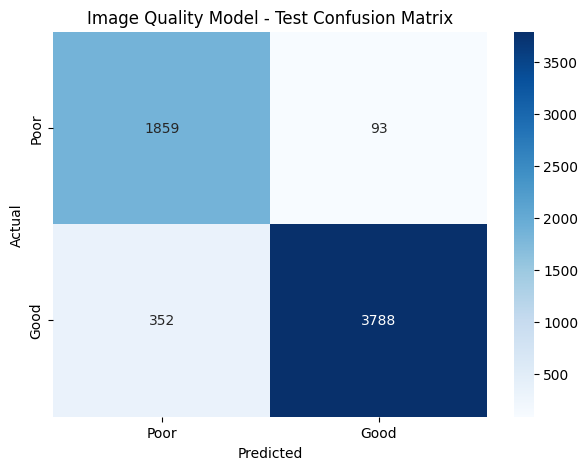

In [146]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

quality_cm = confusion_matrix(
    quality_test_labels,
    quality_test_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    quality_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Poor", "Good"],
    yticklabels=["Poor", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Image Quality Model - Test Confusion Matrix")

plt.show()

In [147]:
quality_results = pd.DataFrame([{
    "Model": "ResNet18 Quality Classifier",
    "Task": "Image Quality Assessment",
    "Test Samples": len(quality_test_labels),
    "Test Loss": quality_test_loss,
    "Test Accuracy": quality_test_accuracy,
    "Macro F1": quality_macro_f1,
    "Weighted F1": quality_weighted_f1
}])

quality_results

,Model,Task,Test Samples,Test Loss,Test Accuracy,Macro F1,Weighted F1
0,ResNet18 Quality Classifier,Image Quality Assessment,6092,0.160701,0.926953,0.918813,0.928046


In [148]:
quality_results.to_csv(
    "/kaggle/working/quality_model_results.csv",
    index=False
)

print("✓ Quality model results saved")

✓ Quality model results saved


In [149]:
import os
import zipfile

files_to_download = [
    "best_efficientnet_b0.pth",
    "best_quality_resnet18.pth",
    "best_resnet18_baseline.pth",
    "best_resnet18_checkpoint.pth",
    "best_resnet18_corrected_split.pth",
    "corrected_unified_metadata.csv",
    "quality_model_results.csv",
    "resnet18_baseline_results.csv",
    "resnet18_final_test_results.csv"
]

source_folder = "/kaggle/working"
zip_path = "/kaggle/working/DR_Project_Models_and_Results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    
    for filename in files_to_download:
        
        file_path = os.path.join(source_folder, filename)
        
        if os.path.exists(file_path):
            zipf.write(
                file_path,
                arcname=filename
            )
            print(f"✓ Added: {filename}")
        else:
            print(f"✗ NOT FOUND: {filename}")

print("\nZIP created successfully:")
print(zip_path)

✓ Added: best_efficientnet_b0.pth
✓ Added: best_quality_resnet18.pth
✓ Added: best_resnet18_baseline.pth
✓ Added: best_resnet18_checkpoint.pth
✓ Added: best_resnet18_corrected_split.pth
✓ Added: corrected_unified_metadata.csv
✓ Added: quality_model_results.csv
✓ Added: resnet18_baseline_results.csv
✓ Added: resnet18_final_test_results.csv

ZIP created successfully:
/kaggle/working/DR_Project_Models_and_Results.zip


In [152]:
import os
import zipfile
from IPython.display import FileLink, display

files_to_download = [
    "best_efficientnet_b0.pth",
    "best_quality_resnet18.pth",
    "best_resnet18_baseline.pth",
    "best_resnet18_checkpoint.pth",
    "best_resnet18_corrected_split.pth",
    "corrected_unified_metadata.csv",
    "quality_model_results.csv",
    "resnet18_baseline_results.csv",
    "resnet18_final_test_results.csv"
]

zip_path = "/kaggle/working/DR_Project_Models_and_Results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in files_to_download:
        file_path = f"/kaggle/working/{filename}"

        if os.path.exists(file_path):
            zipf.write(file_path, arcname=filename)
            print(f"✓ Added: {filename}")
        else:
            print(f"✗ Not found: {filename}")

print("\n✓ ZIP READY")

display(FileLink(zip_path))

✓ Added: best_efficientnet_b0.pth
✓ Added: best_quality_resnet18.pth
✓ Added: best_resnet18_baseline.pth
✓ Added: best_resnet18_checkpoint.pth
✓ Added: best_resnet18_corrected_split.pth
✓ Added: corrected_unified_metadata.csv
✓ Added: quality_model_results.csv
✓ Added: resnet18_baseline_results.csv
✓ Added: resnet18_final_test_results.csv

✓ ZIP READY


/kaggle/working/DR_Project_Models_and_Results.zip

In [55]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    classification_report
)

# Convert to numpy arrays just in case
y_true = np.array(quality_test_labels)
y_pred = np.array(quality_test_predictions)
y_prob = np.array(quality_test_probabilities)

# --------------------------------------------------
# 1. Accuracy
# --------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)

# --------------------------------------------------
# 2. Precision - Macro
# --------------------------------------------------
precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# --------------------------------------------------
# 3. Recall - Macro
# --------------------------------------------------
recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# --------------------------------------------------
# 4. F1 Score - Macro
# --------------------------------------------------
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# --------------------------------------------------
# 5. F1 Score - Weighted
# --------------------------------------------------
weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# --------------------------------------------------
# 6. Balanced Accuracy
# --------------------------------------------------
balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

# --------------------------------------------------
# 7. Quadratic Weighted Kappa
# --------------------------------------------------
qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

# --------------------------------------------------
# 8. Cohen's Kappa
# --------------------------------------------------
kappa = cohen_kappa_score(
    y_true,
    y_pred
)

# --------------------------------------------------
# 9. Matthews Correlation Coefficient
# --------------------------------------------------
mcc = matthews_corrcoef(
    y_true,
    y_pred
)

# --------------------------------------------------
# 10. ROC-AUC
# For binary quality classification
# --------------------------------------------------

# If probabilities have shape (samples, 2)
if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    positive_probabilities = y_prob[:, 1]
else:
    positive_probabilities = y_prob

roc_auc = roc_auc_score(
    y_true,
    positive_probabilities
)

# --------------------------------------------------
# 11. Log Loss
# --------------------------------------------------
logloss = log_loss(
    y_true,
    y_prob
)

# --------------------------------------------------
# PRINT ALL METRICS
# --------------------------------------------------

print("=" * 45)
print("QUALITY ASSESSMENT MODEL - TEST METRICS")
print("=" * 45)

print(f"Accuracy              : {accuracy:.4f}")
print(f"Macro Precision       : {precision_macro:.4f}")
print(f"Macro Recall          : {recall_macro:.4f}")
print(f"Macro F1              : {macro_f1:.4f}")
print(f"Weighted F1           : {weighted_f1:.4f}")
print(f"Balanced Accuracy     : {balanced_accuracy:.4f}")
print(f"QWK                   : {qwk:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"MCC                   : {mcc:.4f}")
print(f"ROC-AUC               : {roc_auc:.4f}")
print(f"Log Loss              : {logloss:.4f}")

NameError: name 'quality_test_labels' is not defined

In [41]:
import torch
import numpy as np

def get_predictions(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            _, predictions = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [157]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 5

resnet18 = models.resnet18(weights=None)

resnet18.fc = nn.Linear(
    resnet18.fc.in_features,
    NUM_CLASSES
)

resnet18.load_state_dict(
    torch.load(
        "/kaggle/working/best_resnet18_baseline.pth",
        map_location=device
    )
)

resnet18 = resnet18.to(device)

print("✓ ResNet18 DR model loaded")

✓ ResNet18 DR model loaded


In [158]:
resnet_y_true, resnet_y_pred, resnet_y_prob = get_predictions(
    resnet18,
    test_loader,
    device
)

print("Labels shape:", resnet_y_true.shape)
print("Predictions shape:", resnet_y_pred.shape)
print("Probabilities shape:", resnet_y_prob.shape)

Labels shape: (6092,)
Predictions shape: (6092,)
Probabilities shape: (6092, 5)


In [37]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)

def calculate_multiclass_metrics(y_true, y_pred, y_prob, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    loss = log_loss(
        y_true,
        y_prob,
        labels=[0, 1, 2, 3, 4]
    )

    print("\n" + "=" * 50)
    print(f"{model_name} - TEST METRICS")
    print("=" * 50)

    print(f"Accuracy              : {accuracy:.4f}")
    print(f"Macro Precision       : {macro_precision:.4f}")
    print(f"Macro Recall          : {macro_recall:.4f}")
    print(f"Macro F1              : {macro_f1:.4f}")
    print(f"Weighted F1           : {weighted_f1:.4f}")
    print(f"Balanced Accuracy     : {balanced_acc:.4f}")
    print(f"QWK                   : {qwk:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")
    print(f"MCC                   : {mcc:.4f}")
    print(f"ROC-AUC               : {roc_auc:.4f}")
    print(f"Log Loss              : {loss:.4f}")

    metrics_dict = {
        "Model": model_name,
        "Task": "DR Severity Classification",
        "Test Samples": len(y_true),
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Balanced Accuracy": balanced_acc,
        "QWK": qwk,
        "Cohen Kappa": kappa,
        "MCC": mcc,
        "ROC-AUC": roc_auc,
        "Log Loss": loss
    }

    return metrics_dict

In [160]:
resnet_metrics = calculate_multiclass_metrics(
    resnet_y_true,
    resnet_y_pred,
    resnet_y_prob,
    "ResNet18 DR"
)


ResNet18 DR - TEST METRICS
Accuracy              : 0.5809
Macro Precision       : 0.4658
Macro Recall          : 0.6467
Macro F1              : 0.4886
Weighted F1           : 0.6337
Balanced Accuracy     : 0.6467
QWK                   : 0.6282
Cohen's Kappa         : 0.3316
MCC                   : 0.3677
ROC-AUC               : 0.8711
Log Loss              : 0.9382


In [164]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 5

# Create EfficientNet-B0 architecture
efficientnet = models.efficientnet_b0(weights=None)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    NUM_CLASSES
)

# Load checkpoint
checkpoint = torch.load(
    "/kaggle/working/best_efficientnet_b0.pth",
    map_location=device
)

# Check what is inside
print(checkpoint.keys())

# Load ONLY the model weights
efficientnet.load_state_dict(
    checkpoint["model_state_dict"]
)

efficientnet = efficientnet.to(device)

print("✓ EfficientNet-B0 loaded successfully")
print("Saved Epoch:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["val_loss"])
print("Validation Accuracy:", checkpoint["val_accuracy"])

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_accuracy', 'history'])
✓ EfficientNet-B0 loaded successfully
Saved Epoch: 3
Validation Loss: 1.0408408580762496
Validation Accuracy: 0.5561391989494419


In [165]:
efficientnet_y_true, efficientnet_y_pred, efficientnet_y_prob = get_predictions(
    efficientnet,
    test_loader,
    device
)

print("Labels:", efficientnet_y_true.shape)
print("Predictions:", efficientnet_y_pred.shape)
print("Probabilities:", efficientnet_y_prob.shape)

Labels: (6092,)
Predictions: (6092,)
Probabilities: (6092, 5)


In [166]:
efficientnet_metrics = calculate_multiclass_metrics(
    efficientnet_y_true,
    efficientnet_y_pred,
    efficientnet_y_prob,
    "EfficientNet-B0 DR"
)


EfficientNet-B0 DR - TEST METRICS
Accuracy              : 0.5486
Macro Precision       : 0.4271
Macro Recall          : 0.5377
Macro F1              : 0.4453
Weighted F1           : 0.6039
Balanced Accuracy     : 0.5377
QWK                   : 0.5844
Cohen's Kappa         : 0.2814
MCC                   : 0.3113
ROC-AUC               : 0.8291
Log Loss              : 0.9969


In [7]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

# Get training labels
train_labels = train_df["label_dr_standard"].astype(int).values

# Define all classes
classes = np.array([0, 1, 2, 3, 4])

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

# Convert to PyTorch tensor
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")
for cls, weight in zip(classes, class_weights.cpu().numpy()):
    print(f"Class {cls}: {weight:.4f}")

NameError: name 'train_df' is not defined

In [38]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 5

# Load pretrained ResNet18
improved_resnet = models.resnet18(weights="IMAGENET1K_V1")

# Replace final classification layer
in_features = improved_resnet.fc.in_features

improved_resnet.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

improved_resnet = improved_resnet.to(device)

print("Improved ResNet18 created successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Improved ResNet18 created successfully


In [39]:
criterion_weighted = nn.CrossEntropyLoss(
    weight=class_weights
)

In [40]:
optimizer_weighted = torch.optim.AdamW(
    improved_resnet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [41]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_weighted,
    mode="min",
    factor=0.5,
    patience=2
)

In [59]:
EPOCHS = 10

history_weighted = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    # Training
    train_loss, train_accuracy = train_one_epoch(
        improved_resnet,
        train_loader,
        criterion_weighted,
        optimizer_weighted,
        device
    )

    # Validation
    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        improved_resnet,
        val_loader,
        criterion_weighted,
        device
    )

    # Save history
    history_weighted["train_loss"].append(train_loss)
    history_weighted["train_accuracy"].append(train_accuracy)
    history_weighted["val_loss"].append(val_loss)
    history_weighted["val_accuracy"].append(val_accuracy)

    # Update scheduler
    scheduler.step(val_loss)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # Save best checkpoint
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": improved_resnet.state_dict(),
            "optimizer_state_dict": optimizer_weighted.state_dict(),
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "history": history_weighted,
            "class_weights": class_weights.cpu()
        }

        torch.save(
            checkpoint,
            "/kaggle/working/best_resnet18_weighted.pth"
        )

        print("✓ Best weighted model saved")


Epoch 1/10
Train Loss: 0.4902 | Train Accuracy: 0.7427
Val Loss: 1.3368 | Val Accuracy: 0.6501
✓ Best weighted model saved

Epoch 2/10
Train Loss: 0.4440 | Train Accuracy: 0.7622
Val Loss: 1.4597 | Val Accuracy: 0.6869

Epoch 3/10
Train Loss: 0.4027 | Train Accuracy: 0.7814
Val Loss: 1.5449 | Val Accuracy: 0.6859

Epoch 4/10
Train Loss: 0.3470 | Train Accuracy: 0.8095
Val Loss: 1.6032 | Val Accuracy: 0.6905

Epoch 5/10
Train Loss: 0.3202 | Train Accuracy: 0.8254
Val Loss: 1.6750 | Val Accuracy: 0.7010

Epoch 6/10
Train Loss: 0.2977 | Train Accuracy: 0.8347
Val Loss: 1.6959 | Val Accuracy: 0.7026

Epoch 7/10
Train Loss: 0.2667 | Train Accuracy: 0.8524
Val Loss: 1.7811 | Val Accuracy: 0.7103

Epoch 8/10
Train Loss: 0.2537 | Train Accuracy: 0.8564
Val Loss: 1.7709 | Val Accuracy: 0.7129

Epoch 9/10
Train Loss: 0.2475 | Train Accuracy: 0.8621
Val Loss: 1.8375 | Val Accuracy: 0.7280

Epoch 10/10
Train Loss: 0.2289 | Train Accuracy: 0.8666
Val Loss: 1.8668 | Val Accuracy: 0.7151


In [46]:
# Recreate model
best_weighted_resnet = models.resnet18(weights=None)

best_weighted_resnet.fc = nn.Linear(
    best_weighted_resnet.fc.in_features,
    NUM_CLASSES
)

best_weighted_resnet = best_weighted_resnet.to(device)

# Load checkpoint
checkpoint = torch.load(
    "/kaggle/working/best_resnet18_weighted.pth",
    map_location=device
)

best_weighted_resnet.load_state_dict(
    checkpoint["model_state_dict"]
)

best_weighted_resnet.eval()

print("✓ Best weighted ResNet18 loaded")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best validation accuracy:", checkpoint["val_accuracy"])

✓ Best weighted ResNet18 loaded
Best epoch: 4
Best validation loss: 1.0614848497962763
Best validation accuracy: 0.6393992055610725


In [50]:
weighted_y_true, weighted_y_pred, weighted_y_prob = get_predictions(
    best_weighted_resnet,
    test_loader,
    device
)

print("Test samples:", len(weighted_y_true))

Test samples: 27


In [58]:
weighted_resnet_metrics = calculate_multiclass_metrics(
    weighted_y_true,
    weighted_y_pred,
    weighted_y_prob,
    "ResNet18 Weighted DR"
)

ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'

In [55]:
import numpy as np

print("Unique classes in test set:", np.unique(weighted_y_true))
print("Number of unique classes:", len(np.unique(weighted_y_true)))

print("Probability shape:", weighted_y_prob.shape)
print("Prediction shape:", weighted_y_pred.shape)

Unique classes in test set: [1 2 3 4]
Number of unique classes: 4
Probability shape: (27, 5)
Prediction shape: (27,)


In [54]:
print(df["model_split"].value_counts())

print("\nTest class distribution:")
print(
    df[df["model_split"] == "test"]["label_dr_standard"]
    .value_counts()
    .sort_index()
)

model_split
train    28429
val       6092
test      6092
Name: count, dtype: int64

Test class distribution:
label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [53]:
import pandas as pd

CORRECTED_METADATA_PATH = "/kaggle/input/datasets/aditik1234/corrected-unified-dataset/corrected_unified_metadata.csv"

df = pd.read_csv(CORRECTED_METADATA_PATH)

print(df["model_split"].value_counts())

model_split
train    28429
val       6092
test      6092
Name: count, dtype: int64


In [4]:
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = "/kaggle/input/datasets/aditik1234/new-model-dr/best_resnet18_weighted (1).pth"

NUM_CLASSES = 5

# Create the same ResNet18 architecture
weighted_resnet = models.resnet18(weights=None)

weighted_resnet.fc = nn.Linear(
    weighted_resnet.fc.in_features,
    NUM_CLASSES
)

# Load checkpoint
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

print("Checkpoint keys:")
print(checkpoint.keys())

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_accuracy', 'history', 'class_weights'])


In [5]:
weighted_resnet.load_state_dict(
    checkpoint["model_state_dict"]
)

weighted_resnet = weighted_resnet.to(device)

weighted_resnet.eval()

print("✓ Weighted ResNet18 loaded successfully")
print("Best epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

✓ Weighted ResNet18 loaded successfully
Best epoch: 1
Validation loss: 1.3368254609946106
Validation accuracy: 0.6500744786494538


In [22]:
import os

CORRECTED_PATH = "/kaggle/input/datasets/aditik1234/corrected-unified-dataset"

print("Files in corrected dataset:")
print(os.listdir(CORRECTED_PATH))

Files in corrected dataset:
['corrected_unified_metadata.csv']


In [23]:
import pandas as pd

METADATA_PATH = "/kaggle/input/datasets/aditik1234/corrected-unified-dataset/corrected_unified_metadata.csv"

df = pd.read_csv(METADATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (40613, 46)

Columns:
['dataset', 'image_key', 'image_id', 'source_split', 'official_split', 'image_path', 'extension', 'label_dr', 'has_label', 'label_source', 'is_readable', 'width', 'height', 'pil_format', 'validation_error', 'label_dr_standard', 'dr_grade_name', 'eligible_for_model', 'model_split', 'split_reason', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'dark_pixel_fraction', 'bright_pixel_fraction', 'quality_flag_auto', 'quality_label', 'quality_label_source', 'duplicate_group', 'duplicate_type', 'review_status', 'processed_path', 'processed_width', 'processed_height', 'processed_format', 'preprocess_status', 'dataset_source', 'dme_label', 'dme_label_source', 'dme_label_scheme', 'lesion_available', 'lesion_annotation_type', 'patient_id', 'patient_id_status', 'final_image_path', 'path_exists']


In [24]:
print(df["model_split"].value_counts(dropna=False))

model_split
train    28429
val       6092
test      6092
Name: count, dtype: int64


In [25]:
train_df = df[df["model_split"] == "train"].copy()

val_df = df[df["model_split"] == "val"].copy()

test_df = df[df["model_split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 28429
Validation: 6092
Test: 6092


In [26]:
print("\nTRAIN:")
print(train_df["label_dr_standard"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["label_dr_standard"].value_counts().sort_index())

print("\nTEST:")
print(test_df["label_dr_standard"].value_counts().sort_index())


TRAIN:
label_dr_standard
0    20042
1     2160
2     4670
3      814
4      743
Name: count, dtype: int64

VALIDATION:
label_dr_standard
0    4295
1     462
2    1001
3     175
4     159
Name: count, dtype: int64

TEST:
label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [32]:
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = DRDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 28429
Validation dataset: 6092
Test dataset: 6092


In [33]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✓ Corrected loaders ready")

✓ Corrected loaders ready


In [34]:
images, labels = next(iter(test_loader))

print("Test samples:", len(test_dataset))
print("Batch shape:", images.shape)
print("First 10 labels:", labels[:10])

Test samples: 6092
Batch shape: torch.Size([32, 3, 224, 224])
First 10 labels: tensor([0, 0, 0, 0, 0, 2, 0, 2, 1, 0])


In [35]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTest classes:")
print(test_df["label_dr_standard"].value_counts().sort_index())

Train: 28429
Validation: 6092
Test: 6092

Test classes:
label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [26]:
weighted_y_true, weighted_y_pred, weighted_y_prob = get_predictions(
    weighted_resnet,
    test_loader,
    device
)

print("Test samples:", len(weighted_y_true))
print("Unique true classes:", np.unique(weighted_y_true))
print("Probability shape:", weighted_y_prob.shape)

Test samples: 6092
Unique true classes: [0 1 2 3 4]
Probability shape: (6092, 5)


In [29]:
weighted_resnet_metrics = calculate_multiclass_metrics(
    weighted_y_true,
    weighted_y_pred,
    weighted_y_prob,
    "ResNet18 Weighted DR"
)


ResNet18 Weighted DR - TEST METRICS
Accuracy              : 0.7431
Macro Precision       : 0.6775
Macro Recall          : 0.7979
Macro F1              : 0.7087
Weighted F1           : 0.7724
Balanced Accuracy     : 0.7979
QWK                   : 0.7628
Cohen's Kappa         : 0.5456
MCC                   : 0.5724
ROC-AUC               : 0.9439
Log Loss              : 0.6161


In [1]:
EFFNET_PATH = "/kaggle/input/datasets/aditik1234/dataset-resent-effifientnet/best_efficientnet_b0.pth"

In [2]:
import os

print("Files in new-model-dr:")

MODEL_DIR = "/kaggle/input/datasets/aditik1234/new-model-dr"

for f in os.listdir(MODEL_DIR):
    print(f)

Files in new-model-dr:
best_resnet18_weighted (1).pth


In [3]:
RESNET_PATH = "/kaggle/input/datasets/aditik1234/dataset-resent-effifientnet/best_resnet18_baseline.pth"

EFFNET_PATH = "/kaggle/input/datasets/aditik1234/dataset-resent-effifientnet/best_efficientnet_b0.pth"

In [4]:
import torch
import torch.nn as nn
import numpy as np

from torchvision import models
from torch.utils.data import DataLoader

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [6]:
NUM_CLASSES = 5

resnet = models.resnet18(weights=None)

resnet.fc = nn.Linear(
    resnet.fc.in_features,
    NUM_CLASSES
)

resnet_checkpoint = torch.load(
    RESNET_PATH,
    map_location=device
)

print("ResNet checkpoint type:", type(resnet_checkpoint))

ResNet checkpoint type: <class 'collections.OrderedDict'>


In [7]:
if "model_state_dict" in resnet_checkpoint:
    resnet.load_state_dict(
        resnet_checkpoint["model_state_dict"]
    )
else:
    resnet.load_state_dict(
        resnet_checkpoint
    )

resnet = resnet.to(device)

print("✓ ResNet18 loaded")

✓ ResNet18 loaded


In [8]:
efficientnet = models.efficientnet_b0(
    weights=None
)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    NUM_CLASSES
)

In [9]:
eff_checkpoint = torch.load(
    EFFNET_PATH,
    map_location=device
)

print("EfficientNet checkpoint keys:")

if isinstance(eff_checkpoint, dict):
    print(eff_checkpoint.keys())

EfficientNet checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_accuracy', 'history'])


In [10]:
if "model_state_dict" in eff_checkpoint:
    efficientnet.load_state_dict(
        eff_checkpoint["model_state_dict"]
    )
else:
    efficientnet.load_state_dict(
        eff_checkpoint
    )

efficientnet = efficientnet.to(device)

print("✓ EfficientNet-B0 loaded")

✓ EfficientNet-B0 loaded


In [11]:
resnet_features = nn.Sequential(
    *list(resnet.children())[:-1]
)

In [12]:
efficientnet_features = efficientnet.features

In [13]:
efficientnet_pool = nn.AdaptiveAvgPool2d(
    (1, 1)
)

In [14]:
for param in resnet_features.parameters():
    param.requires_grad = False

for param in efficientnet_features.parameters():
    param.requires_grad = False

In [15]:
class ResNetEfficientNetFusion(nn.Module):

    def __init__(
        self,
        resnet_features,
        efficientnet_features,
        efficientnet_pool,
        num_classes=5
    ):
        super().__init__()

        self.resnet_features = resnet_features
        self.efficientnet_features = efficientnet_features
        self.efficientnet_pool = efficientnet_pool

        # ResNet18 = 512
        # EfficientNet-B0 = 1280
        fused_features = 512 + 1280

        self.fusion = nn.Sequential(

            nn.Linear(
                fused_features,
                512
            ),

            nn.ReLU(),

            nn.BatchNorm1d(512),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        # ResNet features
        r = self.resnet_features(x)

        r = torch.flatten(
            r,
            start_dim=1
        )

        # EfficientNet features
        e = self.efficientnet_features(x)

        e = self.efficientnet_pool(e)

        e = torch.flatten(
            e,
            start_dim=1
        )

        # Feature fusion
        fused = torch.cat(
            [r, e],
            dim=1
        )

        output = self.fusion(fused)

        return output

In [16]:
fusion_model = ResNetEfficientNetFusion(
    resnet_features,
    efficientnet_features,
    efficientnet_pool,
    num_classes=5
)

fusion_model = fusion_model.to(device)

print(fusion_model)

ResNetEfficientNetFusion(
  (resnet_features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [18]:
class_weights = torch.tensor(
    [0.2840, 2.6244, 1.2147, 6.9807, 7.6094],
    dtype=torch.float32
).to(device)

criterion_fusion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [19]:
optimizer_fusion = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        fusion_model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [20]:
scheduler_fusion = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fusion,
    mode="min",
    factor=0.5,
    patience=2
)

In [36]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 28429
Validation: 6092
Test: 6092


In [37]:
print(
    test_df["label_dr_standard"]
    .value_counts()
    .sort_index()
)

label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [38]:
EPOCHS = 10

fusion_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    # -----------------------------
    # TRAIN
    # -----------------------------

    fusion_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_fusion.zero_grad()

        outputs = fusion_model(images)

        loss = criterion_fusion(
            outputs,
            labels
        )

        loss.backward()

        optimizer_fusion.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -----------------------------
    # VALIDATION
    # -----------------------------

    fusion_model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = fusion_model(images)

            loss = criterion_fusion(
                outputs,
                labels
            )

            val_loss_total += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    scheduler_fusion.step(val_loss)

    fusion_history["train_loss"].append(
        train_loss
    )

    fusion_history["train_accuracy"].append(
        train_accuracy
    )

    fusion_history["val_loss"].append(
        val_loss
    )

    fusion_history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # -----------------------------
    # SAVE BEST MODEL
    # -----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict":
                    fusion_model.state_dict(),
                "optimizer_state_dict":
                    optimizer_fusion.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "history": fusion_history
            },
            "/kaggle/working/best_resnet18_efficientnet_fusion.pth"
        )

        print("✓ Best fusion model saved") 


Epoch 1/10
Train Loss: 0.9498 | Train Accuracy: 0.6017
Val Loss: 0.9117 | Val Accuracy: 0.5996
✓ Best fusion model saved

Epoch 2/10
Train Loss: 0.8603 | Train Accuracy: 0.6250
Val Loss: 0.9057 | Val Accuracy: 0.6262
✓ Best fusion model saved

Epoch 3/10
Train Loss: 0.8402 | Train Accuracy: 0.6295
Val Loss: 0.8991 | Val Accuracy: 0.6275
✓ Best fusion model saved

Epoch 4/10
Train Loss: 0.8249 | Train Accuracy: 0.6273
Val Loss: 0.8920 | Val Accuracy: 0.6820
✓ Best fusion model saved

Epoch 5/10
Train Loss: 0.8088 | Train Accuracy: 0.6404
Val Loss: 0.9083 | Val Accuracy: 0.6766

Epoch 6/10
Train Loss: 0.8028 | Train Accuracy: 0.6446
Val Loss: 0.8977 | Val Accuracy: 0.6717

Epoch 7/10
Train Loss: 0.7931 | Train Accuracy: 0.6504
Val Loss: 0.8803 | Val Accuracy: 0.6494
✓ Best fusion model saved

Epoch 8/10
Train Loss: 0.7829 | Train Accuracy: 0.6540
Val Loss: 0.8992 | Val Accuracy: 0.5780

Epoch 9/10
Train Loss: 0.7794 | Train Accuracy: 0.6490
Val Loss: 0.9174 | Val Accuracy: 0.6161

Epoch

In [ ]:
import os

path = "/kaggle/working/best_resnet18_efficientnet_fusion.pth"

print("Checkpoint exists:", os.path.exists(path))

if os.path.exists(path):
    print("Size (MB):", os.path.getsize(path) / (1024**2))

In [55]:
print("ResNet checkpoint:", resnet_checkpoint.keys()
      if isinstance(resnet_checkpoint, dict)
      else "state_dict")

print("EfficientNet checkpoint:", eff_checkpoint.keys()
      if isinstance(eff_checkpoint, dict)
      else "state_dict")

ResNet checkpoint: odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'la

In [39]:
fusion_checkpoint = torch.load(
    "/kaggle/working/best_resnet18_efficientnet_fusion.pth",
    map_location=device
)

fusion_model.load_state_dict(
    fusion_checkpoint["model_state_dict"]
)

fusion_model.eval()

print(
    "Best epoch:",
    fusion_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    fusion_checkpoint["val_loss"]
)

Best epoch: 7
Best validation loss: 0.8802752320263938


In [42]:
fusion_y_true, fusion_y_pred, fusion_y_prob = get_predictions(
    fusion_model,
    test_loader,
    device
)

print(
    "Test samples:",
    len(fusion_y_true)
)

print(
    "Classes:",
    np.unique(fusion_y_true)
)

print(
    "Probability shape:",
    fusion_y_prob.shape
)

Test samples: 6092
Classes: [0 1 2 3 4]
Probability shape: (6092, 5)


In [45]:
fusion_metrics = calculate_multiclass_metrics(
    fusion_y_true,
    fusion_y_pred,
    fusion_y_prob,
    "ResNet18 + EfficientNet-B0 Fusion"
)


ResNet18 + EfficientNet-B0 Fusion - TEST METRICS
Accuracy              : 0.6546
Macro Precision       : 0.5031
Macro Recall          : 0.6240
Macro F1              : 0.5342
Weighted F1           : 0.6923
Balanced Accuracy     : 0.6240
QWK                   : 0.6694
Cohen's Kappa         : 0.3954
MCC                   : 0.4150
ROC-AUC               : 0.8766
Log Loss              : 0.8223


In [46]:
quality_cols = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian_var",
    "dark_pixel_fraction",
    "bright_pixel_fraction"
]

print("Quality columns:")
print(quality_cols)

print("\nTrain quality missing values:")
print(train_df[quality_cols].isna().sum())

print("\nValidation quality missing values:")
print(val_df[quality_cols].isna().sum())

print("\nTest quality missing values:")
print(test_df[quality_cols].isna().sum())

Quality columns:
['brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'dark_pixel_fraction', 'bright_pixel_fraction']

Train quality missing values:
brightness_mean            0
contrast_std               0
sharpness_laplacian_var    0
dark_pixel_fraction        0
bright_pixel_fraction      0
dtype: int64

Validation quality missing values:
brightness_mean            0
contrast_std               0
sharpness_laplacian_var    0
dark_pixel_fraction        0
bright_pixel_fraction      0
dtype: int64

Test quality missing values:
brightness_mean            0
contrast_std               0
sharpness_laplacian_var    0
dark_pixel_fraction        0
bright_pixel_fraction      0
dtype: int64


In [47]:
import numpy as np

quality_cols = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian_var",
    "dark_pixel_fraction",
    "bright_pixel_fraction"
]

quality_mean = train_df[quality_cols].mean()
quality_std = train_df[quality_cols].std()

# Avoid division by zero
quality_std = quality_std.replace(0, 1)

train_df[quality_cols] = (
    train_df[quality_cols] - quality_mean
) / quality_std

val_df[quality_cols] = (
    val_df[quality_cols] - quality_mean
) / quality_std

test_df[quality_cols] = (
    test_df[quality_cols] - quality_mean
) / quality_std

print("✓ Quality features normalized")

✓ Quality features normalized


In [48]:
train_df[quality_cols] = train_df[quality_cols].fillna(0)
val_df[quality_cols] = val_df[quality_cols].fillna(0)
test_df[quality_cols] = test_df[quality_cols].fillna(0)

print("Remaining missing values:")
print(train_df[quality_cols].isna().sum())

Remaining missing values:
brightness_mean            0
contrast_std               0
sharpness_laplacian_var    0
dark_pixel_fraction        0
bright_pixel_fraction      0
dtype: int64


In [50]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class DRQualityDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        quality_columns=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.quality_columns = quality_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["processed_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        quality_features = torch.tensor(
            row[self.quality_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        label = torch.tensor(
            int(row["label_dr_standard"]),
            dtype=torch.long
        )

        return image, quality_features, label

In [51]:
BASE_IMAGE_PATH = "/kaggle/input/datasets/aditik1234/processed/processed/images"

def make_kaggle_path(p):

    p = str(p)

    filename = p.split("/")[-1]

    # Extract dataset/source folder
    parts = p.replace("\\", "/").split("/")

    if len(parts) >= 4:
        dataset_name = parts[-2]
    else:
        dataset_name = ""

    return f"{BASE_IMAGE_PATH}/{dataset_name}/{filename}"

In [53]:
train_df["fusion_image_path"] = train_df["processed_path"].apply(
    make_kaggle_path
)

val_df["fusion_image_path"] = val_df["processed_path"].apply(
    make_kaggle_path
)

test_df["fusion_image_path"] = test_df["processed_path"].apply(
    make_kaggle_path
)

In [54]:
class DRQualityDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        quality_columns=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.quality_columns = quality_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["fusion_image_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        quality_features = torch.tensor(
            row[self.quality_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        label = torch.tensor(
            int(row["label_dr_standard"]),
            dtype=torch.long
        )

        return image, quality_features, label

In [55]:
quality_cols = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian_var",
    "dark_pixel_fraction",
    "bright_pixel_fraction"
]

train_quality_dataset = DRQualityDataset(
    train_df,
    transform=train_transform,
    quality_columns=quality_cols
)

val_quality_dataset = DRQualityDataset(
    val_df,
    transform=val_test_transform,
    quality_columns=quality_cols
)

test_quality_dataset = DRQualityDataset(
    test_df,
    transform=val_test_transform,
    quality_columns=quality_cols
)

print("Train:", len(train_quality_dataset))
print("Validation:", len(val_quality_dataset))
print("Test:", len(test_quality_dataset))

Train: 28429
Validation: 6092
Test: 6092


In [56]:
BATCH_SIZE = 32

train_quality_loader = DataLoader(
    train_quality_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_quality_loader = DataLoader(
    val_quality_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_quality_loader = DataLoader(
    test_quality_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [57]:
images, quality, labels = next(
    iter(train_quality_loader)
)

print("Images:", images.shape)
print("Quality:", quality.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Quality: torch.Size([32, 5])
Labels: torch.Size([32])


In [58]:
resnet_features = nn.Sequential(
    *list(resnet.children())[:-1]
)

efficientnet_features = efficientnet.features

efficientnet_pool = nn.AdaptiveAvgPool2d(
    (1, 1)
)

In [60]:
for param in resnet_features.parameters():
    param.requires_grad = False

for param in efficientnet_features.parameters():
    param.requires_grad = False

In [61]:
class MultiModalFusionModel(nn.Module):

    def __init__(
        self,
        resnet_features,
        efficientnet_features,
        efficientnet_pool,
        num_quality_features=5,
        num_classes=5
    ):
        super().__init__()

        self.resnet_features = resnet_features

        self.efficientnet_features = efficientnet_features

        self.efficientnet_pool = efficientnet_pool

        # 512 ResNet
        # 1280 EfficientNet
        # 5 quality features
        fused_dim = 512 + 1280 + num_quality_features

        self.fusion = nn.Sequential(

            nn.Linear(
                fused_dim,
                512
            ),

            nn.ReLU(),

            nn.BatchNorm1d(512),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(
        self,
        image,
        quality
    ):

        # -------------------------
        # ResNet18 branch
        # -------------------------

        r = self.resnet_features(image)

        r = torch.flatten(
            r,
            start_dim=1
        )

        # -------------------------
        # EfficientNet branch
        # -------------------------

        e = self.efficientnet_features(image)

        e = self.efficientnet_pool(e)

        e = torch.flatten(
            e,
            start_dim=1
        )

        # -------------------------
        # Feature fusion
        # -------------------------

        fused = torch.cat(
            [
                r,
                e,
                quality
            ],
            dim=1
        )

        output = self.fusion(fused)

        return output

In [62]:
multimodal_model = MultiModalFusionModel(
    resnet_features=resnet_features,
    efficientnet_features=efficientnet_features,
    efficientnet_pool=efficientnet_pool,
    num_quality_features=5,
    num_classes=5
)

multimodal_model = multimodal_model.to(device)

print("✓ Multimodal fusion model created")

✓ Multimodal fusion model created


In [64]:
class_weights = torch.tensor(
    [0.2840, 2.6244, 1.2147, 6.9807, 7.6094],
    dtype=torch.float32
).to(device)

criterion_multimodal = nn.CrossEntropyLoss(
    weight=class_weights
)

In [65]:
optimizer_multimodal = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        multimodal_model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [67]:
scheduler_multimodal = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_multimodal,
    mode="min",
    factor=0.5,
    patience=2
)

In [68]:
EPOCHS = 10

multimodal_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    # =========================
    # TRAIN
    # =========================

    multimodal_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, quality, labels in train_quality_loader:

        images = images.to(device, non_blocking=True)
        quality = quality.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_multimodal.zero_grad()

        outputs = multimodal_model(
            images,
            quality
        )

        loss = criterion_multimodal(
            outputs,
            labels
        )

        loss.backward()

        optimizer_multimodal.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # =========================
    # VALIDATION
    # =========================

    multimodal_model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, quality, labels in val_quality_loader:

            images = images.to(device, non_blocking=True)
            quality = quality.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = multimodal_model(
                images,
                quality
            )

            loss = criterion_multimodal(
                outputs,
                labels
            )

            val_loss_total += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    scheduler_multimodal.step(val_loss)

    multimodal_history["train_loss"].append(
        train_loss
    )

    multimodal_history["train_accuracy"].append(
        train_accuracy
    )

    multimodal_history["val_loss"].append(
        val_loss
    )

    multimodal_history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # =========================
    # SAVE BEST
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict":
                    multimodal_model.state_dict(),
                "optimizer_state_dict":
                    optimizer_multimodal.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "history": multimodal_history
            },
            "/kaggle/working/best_resnet_efficientnet_quality_fusion.pth"
        )

        print("✓ Best multimodal model saved")


Epoch 1/10
Train Loss: 0.9704 | Train Accuracy: 0.6002
Val Loss: 0.9275 | Val Accuracy: 0.6211
✓ Best multimodal model saved

Epoch 2/10
Train Loss: 0.8656 | Train Accuracy: 0.6335
Val Loss: 0.9107 | Val Accuracy: 0.6111
✓ Best multimodal model saved

Epoch 3/10
Train Loss: 0.8357 | Train Accuracy: 0.6328
Val Loss: 0.8882 | Val Accuracy: 0.6051
✓ Best multimodal model saved

Epoch 4/10
Train Loss: 0.8263 | Train Accuracy: 0.6326
Val Loss: 0.8835 | Val Accuracy: 0.6563
✓ Best multimodal model saved

Epoch 5/10
Train Loss: 0.8062 | Train Accuracy: 0.6355
Val Loss: 0.9005 | Val Accuracy: 0.6453

Epoch 6/10
Train Loss: 0.7963 | Train Accuracy: 0.6452
Val Loss: 0.8773 | Val Accuracy: 0.6418
✓ Best multimodal model saved

Epoch 7/10
Train Loss: 0.7927 | Train Accuracy: 0.6398
Val Loss: 0.8933 | Val Accuracy: 0.6097

Epoch 8/10
Train Loss: 0.7884 | Train Accuracy: 0.6457
Val Loss: 0.9167 | Val Accuracy: 0.6536

Epoch 9/10
Train Loss: 0.7870 | Train Accuracy: 0.6491
Val Loss: 0.8809 | Val Acc

In [69]:
best_multimodal_checkpoint = torch.load(
    "/kaggle/working/best_resnet_efficientnet_quality_fusion.pth",
    map_location=device
)

multimodal_model.load_state_dict(
    best_multimodal_checkpoint["model_state_dict"]
)

multimodal_model.eval()

print(
    "Best epoch:",
    best_multimodal_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    best_multimodal_checkpoint["val_loss"]
)

Best epoch: 6
Best validation loss: 0.8772507906351447


In [72]:
def get_multimodal_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, quality, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            quality = quality.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images,
                quality
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [74]:
multimodal_y_true, multimodal_y_pred, multimodal_y_prob = get_multimodal_predictions(
    multimodal_model,
    test_quality_loader,
    device
)

print("Test samples:", len(multimodal_y_true))
print("Classes:", np.unique(multimodal_y_true))
print("Probability shape:", multimodal_y_prob.shape)

Test samples: 6092
Classes: [0 1 2 3 4]
Probability shape: (6092, 5)


In [ ]:
multimodal_metrics = calculate_multiclass_metrics(
    multimodal_y_true,
    multimodal_y_pred,
    multimodal_y_prob,
    "ResNet18 + EfficientNet-B0 + Quality Fusion"
)

In [1]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from PIL import Image

print("PyTorch:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
CORRECTED_DIR = "/kaggle/input/datasets/aditik1234/corrected-unified-dataset"

print(os.listdir(CORRECTED_DIR))

['corrected_unified_metadata.csv']


In [3]:
METADATA_PATH = (
    "/kaggle/input/datasets/aditik1234/"
    "corrected-unified-dataset/"
    "corrected_unified_metadata.csv"
)

df = pd.read_csv(METADATA_PATH)

print("Shape:", df.shape)
print(df["model_split"].value_counts())

Shape: (40613, 46)
model_split
train    28429
val       6092
test      6092
Name: count, dtype: int64


In [4]:
train_df = df[
    df["model_split"] == "train"
].copy()

val_df = df[
    df["model_split"] == "val"
].copy()

test_df = df[
    df["model_split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 28429
Validation: 6092
Test: 6092


In [5]:
print(
    test_df["label_dr_standard"]
    .value_counts()
    .sort_index()
)

label_dr_standard
0    4295
1     463
2    1001
3     174
4     159
Name: count, dtype: int64


In [6]:
BASE_IMAGE_PATH = (
    "/kaggle/input/datasets/aditik1234/"
    "processed/processed/images"
)

In [7]:
def make_kaggle_image_path(p):

    p = str(p).replace("\\", "/")

    parts = p.split("/")

    # Example:
    # data/processed/images/aptos/file.jpg
    #                         ↑
    #                      dataset

    if len(parts) >= 2:
        dataset_name = parts[-2]
        filename = parts[-1]

        return os.path.join(
            BASE_IMAGE_PATH,
            dataset_name,
            filename
        )

    return None

In [8]:
train_df["fusion_image_path"] = train_df[
    "processed_path"
].apply(make_kaggle_image_path)

val_df["fusion_image_path"] = val_df[
    "processed_path"
].apply(make_kaggle_image_path)

test_df["fusion_image_path"] = test_df[
    "processed_path"
].apply(make_kaggle_image_path)

In [9]:
print(
    "Train existing:",
    train_df["fusion_image_path"].map(os.path.exists).sum(),
    "/",
    len(train_df)
)

print(
    "Validation existing:",
    val_df["fusion_image_path"].map(os.path.exists).sum(),
    "/",
    len(val_df)
)

print(
    "Test existing:",
    test_df["fusion_image_path"].map(os.path.exists).sum(),
    "/",
    len(test_df)
)

Train existing: 28429 / 28429
Validation existing: 6092 / 6092
Test existing: 6092 / 6092


In [10]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
class FusionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["fusion_image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            int(row["label_dr_standard"]),
            dtype=torch.long
        )

        return image, label

In [15]:
train_dataset = FusionDataset(
    train_df,
    transform=train_transform
)

val_dataset = FusionDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = FusionDataset(
    test_df,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 28429
Validation: 6092
Test: 6092


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✓ DataLoaders ready")

✓ DataLoaders ready


In [17]:
RESNET_PATH = (
    "/kaggle/input/datasets/aditik1234/"
    "new-model-dr/"
    "best_resnet18_weighted (1).pth"
)

resnet = models.resnet18(
    weights=None
)

resnet.fc = nn.Linear(
    resnet.fc.in_features,
    5
)

resnet_checkpoint = torch.load(
    RESNET_PATH,
    map_location=device
)

print(type(resnet_checkpoint))

<class 'dict'>


In [18]:
if isinstance(resnet_checkpoint, dict):
    print(resnet_checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_accuracy', 'history', 'class_weights'])


In [19]:
resnet.load_state_dict(
    resnet_checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [20]:
if (
    isinstance(resnet_checkpoint, dict)
    and "model_state_dict" in resnet_checkpoint
):
    resnet.load_state_dict(
        resnet_checkpoint["model_state_dict"]
    )
else:
    resnet.load_state_dict(
        resnet_checkpoint
    )

resnet = resnet.to(device)

print("✓ Weighted ResNet18 loaded")

✓ Weighted ResNet18 loaded


In [22]:
EFFNET_PATH = "/kaggle/input/datasets/aditik1234/dataset-resent-effifientnet/best_efficientnet_b0.pth"

efficientnet = models.efficientnet_b0(
    weights=None
)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    5
)

eff_checkpoint = torch.load(
    EFFNET_PATH,
    map_location=device
)

efficientnet.load_state_dict(
    eff_checkpoint["model_state_dict"]
)

efficientnet = efficientnet.to(device)

print("✓ EfficientNet-B0 loaded")

✓ EfficientNet-B0 loaded


In [23]:
resnet_features = nn.Sequential(
    *list(resnet.children())[:-1]
)

In [24]:
efficientnet_features = efficientnet.features

efficientnet_pool = nn.AdaptiveAvgPool2d(
    (1, 1)
)

In [25]:
for param in resnet_features.parameters():
    param.requires_grad = False

for param in efficientnet_features.parameters():
    param.requires_grad = False

In [26]:
class AttentionFusionModel(nn.Module):

    def __init__(
        self,
        resnet_features,
        efficientnet_features,
        efficientnet_pool,
        num_classes=5
    ):
        super().__init__()

        self.resnet_features = resnet_features

        self.efficientnet_features = (
            efficientnet_features
        )

        self.efficientnet_pool = (
            efficientnet_pool
        )

        # Project both models to same dimension
        self.resnet_projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256)
        )

        self.efficientnet_projection = nn.Sequential(
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256)
        )

        # Learn importance of each branch
        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # -------------------------
        # ResNet branch
        # -------------------------

        r = self.resnet_features(x)

        r = torch.flatten(
            r,
            start_dim=1
        )

        r = self.resnet_projection(r)

        # -------------------------
        # EfficientNet branch
        # -------------------------

        e = self.efficientnet_features(x)

        e = self.efficientnet_pool(e)

        e = torch.flatten(
            e,
            start_dim=1
        )

        e = self.efficientnet_projection(e)

        # -------------------------
        # Attention
        # -------------------------

        combined = torch.cat(
            [r, e],
            dim=1
        )

        attention_logits = self.attention(
            combined
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1
        )

        # -------------------------
        # Weighted fusion
        # -------------------------

        r_weight = attention_weights[:, 0:1]

        e_weight = attention_weights[:, 1:2]

        fused = (
            r * r_weight +
            e * e_weight
        )

        # -------------------------
        # Classification
        # -------------------------

        output = self.classifier(
            fused
        )

        return output, attention_weights

In [27]:
attention_model = AttentionFusionModel(
    resnet_features=resnet_features,
    efficientnet_features=efficientnet_features,
    efficientnet_pool=efficientnet_pool,
    num_classes=5
)

attention_model = attention_model.to(device)

print("✓ Attention fusion model created")

✓ Attention fusion model created


In [28]:
class_weights = torch.tensor(
    [
        0.2840,
        2.6244,
        1.2147,
        6.9807,
        7.6094
    ],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("✓ Class-weighted loss ready")

✓ Class-weighted loss ready


In [29]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        attention_model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [30]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

SAVE_PATH = (
    "/kaggle/working/"
    "best_weighted_resnet_efficientnet_attention.pth"
)

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    # ==================================
    # TRAIN
    # ==================================

    attention_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs, attention_weights = (
            attention_model(images)
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ==================================
    # VALIDATION
    # ==================================

    attention_model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs, attention_weights = (
                attention_model(images)
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss_total += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # ==================================
    # SAVE BEST
    # ==================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    attention_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy,

                "history":
                    history
            },
            SAVE_PATH
        )

        print(
            "✓ BEST ATTENTION FUSION MODEL SAVED"
        )


Epoch 1/10
Train Loss: 0.8861 | Train Accuracy: 0.5867
Val Loss: 0.6171 | Val Accuracy: 0.7342
✓ BEST ATTENTION FUSION MODEL SAVED

Epoch 2/10
Train Loss: 0.6772 | Train Accuracy: 0.7122
Val Loss: 0.5747 | Val Accuracy: 0.7280
✓ BEST ATTENTION FUSION MODEL SAVED

Epoch 3/10
Train Loss: 0.6482 | Train Accuracy: 0.7258
Val Loss: 0.5872 | Val Accuracy: 0.7270

Epoch 4/10
Train Loss: 0.6299 | Train Accuracy: 0.7269
Val Loss: 0.6195 | Val Accuracy: 0.7649

Epoch 5/10
Train Loss: 0.6197 | Train Accuracy: 0.7299
Val Loss: 0.6053 | Val Accuracy: 0.7195

Epoch 6/10
Train Loss: 0.5958 | Train Accuracy: 0.7338
Val Loss: 0.5830 | Val Accuracy: 0.7751

Epoch 7/10
Train Loss: 0.5972 | Train Accuracy: 0.7387
Val Loss: 0.5816 | Val Accuracy: 0.7438

Epoch 8/10
Train Loss: 0.5890 | Train Accuracy: 0.7367
Val Loss: 0.5769 | Val Accuracy: 0.7400

Epoch 9/10
Train Loss: 0.5679 | Train Accuracy: 0.7453
Val Loss: 0.5959 | Val Accuracy: 0.7659

Epoch 10/10
Train Loss: 0.5747 | Train Accuracy: 0.7403
Val Los

In [31]:
import os

print(
    "Saved:",
    os.path.exists(SAVE_PATH)
)

if os.path.exists(SAVE_PATH):

    size_mb = (
        os.path.getsize(SAVE_PATH)
        / (1024 ** 2)
    )

    print(
        f"Size: {size_mb:.2f} MB"
    )

Saved: True
Size: 64.84 MB


In [32]:
best_checkpoint = torch.load(
    SAVE_PATH,
    map_location=device
)

attention_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

attention_model.eval()

print(
    "Best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    best_checkpoint["val_loss"]
)

print(
    "Best validation accuracy:",
    best_checkpoint["val_accuracy"]
)

Best epoch: 2
Best validation loss: 0.5747243009033128
Best validation accuracy: 0.7280039395929088


In [33]:
def get_attention_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    all_attention = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs, attention_weights = (
                model(images)
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = outputs.argmax(
                dim=1
            )

            all_true.extend(
                labels.numpy()
            )

            all_pred.extend(
                predictions.cpu().numpy()
            )

            all_prob.extend(
                probabilities.cpu().numpy()
            )

            all_attention.extend(
                attention_weights.cpu().numpy()
            )

    return (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_prob),
        np.array(all_attention)
    )

In [34]:
attention_y_true, attention_y_pred, attention_y_prob, attention_weights = (
    get_attention_predictions(
        attention_model,
        test_loader,
        device
    )
)

In [35]:
print(
    "Test samples:",
    len(attention_y_true)
)

print(
    "Classes:",
    np.unique(attention_y_true)
)

print(
    "Probability shape:",
    attention_y_prob.shape
)

print(
    "Attention shape:",
    attention_weights.shape
)

Test samples: 6092
Classes: [0 1 2 3 4]
Probability shape: (6092, 5)
Attention shape: (6092, 2)


In [38]:
attention_metrics = calculate_multiclass_metrics(
    attention_y_true,
    attention_y_pred,
    attention_y_prob,
    "Weighted ResNet18 + EfficientNet Attention Fusion"
)


Weighted ResNet18 + EfficientNet Attention Fusion - TEST METRICS
Accuracy              : 0.7326
Macro Precision       : 0.6487
Macro Recall          : 0.7975
Macro F1              : 0.6907
Weighted F1           : 0.7616
Balanced Accuracy     : 0.7975
QWK                   : 0.7418
Cohen's Kappa         : 0.5319
MCC                   : 0.5598
ROC-AUC               : 0.9397
Log Loss              : 0.6580


In [39]:
fusion_result = {
    "Model": "Weighted ResNet18 + EfficientNet Attention Fusion",
    "Accuracy": 0.7326,
    "Macro Precision": 0.6487,
    "Macro Recall": 0.7975,
    "Macro F1": 0.6907,
    "Weighted F1": 0.7616,
    "Balanced Accuracy": 0.7975,
    "QWK": 0.7418,
    "Cohen Kappa": 0.5319,
    "MCC": 0.5598,
    "ROC-AUC": 0.9397,
    "Log Loss": 0.6580
}

print(fusion_result)

{'Model': 'Weighted ResNet18 + EfficientNet Attention Fusion', 'Accuracy': 0.7326, 'Macro Precision': 0.6487, 'Macro Recall': 0.7975, 'Macro F1': 0.6907, 'Weighted F1': 0.7616, 'Balanced Accuracy': 0.7975, 'QWK': 0.7418, 'Cohen Kappa': 0.5319, 'MCC': 0.5598, 'ROC-AUC': 0.9397, 'Log Loss': 0.658}
